# Do DL models and training environments have an impact on the energy consumption of computer vision training?

## RQ3.2: Which parameters can help estimate energy consumption?

Author: Santiago del Rey


## Import libraries


In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from tqdm import tqdm

from src.environment import CONFIGS_DIR, DATA_DIR, FIGURES_DIR, METRICS_DIR
from src.features.analysis import build_energy_estimation, find_stabilizing_point, plot_regime_change
from src.features.preprocessing import (
    HOURS_TO_SECONDS,
    JOULES_TO_KJOULES,
    KJOULES_TO_JOULES,
    MJOULES_TO_JOULES,
    MJOULES_TO_KJOULES,
    get_epoch_ends,
)

SAVE_FIGS = True
FIGURES_FORMAT = "pdf"
SAVE_FIGS_DIR = FIGURES_DIR / "RQ4"

if not SAVE_FIGS_DIR.exists():
    os.makedirs(SAVE_FIGS_DIR)

# Set numpy random seed for reproducibility
rng = np.random.default_rng(seed=2024)

sns.set_theme(style="whitegrid", context="paper", palette="colorblind", color_codes=True, font_scale=1.5)
plt.style.use(CONFIGS_DIR / "figures.mplstyle")

%matplotlib inline

## Utility functions and constants


In [2]:
INDEPENDENT_VARIABLES = [
    "training environment",
    "architecture",
    "dataset",
    "batch size",
    "image size",
    "total ram (GB)",
]
RELEVANT_METRICS = [
    "run_id",
    "start time",
    "training duration (h)",
    "return code",
    "gpu usage (%)",
    "average gpu power (W)",
    "gpu energy (MJ)",
    "max power limit (W)",
    "average ram power (W)",
    "ram energy (MJ)",
    "energy (MJ)",
    "GFLOPs",
    "trained epochs",
    "measured epochs",
    "total seen images",
]

## Load the datasets


In [3]:
aggregated_metrics = pd.read_parquet(
    METRICS_DIR / "processed" / "clean-dl-training-energy-consumption-dataset.gzip",
    columns=INDEPENDENT_VARIABLES + RELEVANT_METRICS,
).sort_values(by=["start time"])

aggregated_metrics.replace(
    {
        "Desktop Normal User": "Desktop N",
        "Desktop ML Engineer": "Desktop ML",
    },
    inplace=True,
)

aggregated_metrics.head()

,training environment,architecture,dataset,batch size,image size,total ram (GB),run_id,start time,training duration (h),return code,...,average gpu power (W),gpu energy (MJ),max power limit (W),average ram power (W),ram energy (MJ),energy (MJ),GFLOPs,trained epochs,measured epochs,total seen images
0,Server,mobilenet_v2,chesslive-occupancy,32,"(128, 128)",16.0,ed5f9d5907ee495fb655e7e90aff1fac,2022-12-05 09:55:44.537,0.735028,0.0,...,156.930408,0.415289,350.0,4.702747,0.012444,0.427733,0.064028,89,86,2919872
1,Server,mobilenet_v2,chesslive-occupancy,32,"(128, 128)",16.0,782109dee17a4c399030b0822155591f,2022-12-05 10:47:16.997,0.796192,0.0,...,153.356494,0.439651,350.0,4.813751,0.013798,0.453448,0.064028,93,92,3123584
2,Server,mobilenet_v2,chesslive-occupancy,32,"(128, 128)",16.0,b85c1287f4344b7996bffcd15d890d86,2022-12-05 11:41:08.533,0.472226,0.0,...,150.298999,0.255596,350.0,4.828642,0.008209,0.263805,0.064028,56,55,1867360
3,Server,mobilenet_v2,chesslive-occupancy,32,"(128, 128)",16.0,5a4800e73d8241b19bb9369dd74295f9,2022-12-05 12:15:34.087,0.634343,0.0,...,156.511394,0.357506,350.0,4.841027,0.011055,0.368561,0.064028,75,74,2512448
4,Server,mobilenet_v2,chesslive-occupancy,32,"(128, 128)",16.0,29bb5be7abd140b68c106c87604df9a9,2022-12-05 12:59:41.666,0.662704,0.0,...,149.651426,0.357111,350.0,4.855310,0.011583,0.368695,0.064028,77,76,2580352


In [4]:
metrics = pd.read_parquet(os.path.join(METRICS_DIR, "interim", "dl-training-profiling-dataset.gzip"))
metrics.query("`run_id` in @aggregated_metrics['run_id'].values", inplace=True)
metrics["elapsed_time"] = metrics["elapsed_time"] / np.timedelta64(1, "s")
metrics["epoch"] = metrics["epoch"].astype("int")

metrics.head()

,train_environment,architecture,dataset,run_id,timestamp,gpu_name,gpu_usage,gpu_memory_usage,gpu_total_memory,gpu_memory_used,gpu_power_draw,gpu_max_power,gpu_temperature,cpu_usage,memory_usage,total_memory,memory_power_draw,elapsed_time,creation_time,epoch
0,server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,2023-12-18 20:52:07.470,NVIDIA GeForce RTX 3090,0.0,0.0,24576.0,22724.0,111.0,350.0,48.0,5.000,1810.870972,16.0,0.679077,0.000,20231218T205204,0
1,server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,2023-12-18 20:52:08.471,NVIDIA GeForce RTX 3090,0.0,0.0,24576.0,22724.0,111.0,350.0,48.0,4.167,1814.616943,16.0,0.680481,1.001,20231218T205204,0
2,server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,2023-12-18 20:52:09.474,NVIDIA GeForce RTX 3090,0.0,0.0,24576.0,22724.0,111.0,350.0,48.0,3.679,1849.836060,16.0,0.693689,2.004,20231218T205204,0
3,server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,2023-12-18 20:52:10.475,NVIDIA GeForce RTX 3090,0.0,0.0,24576.0,22724.0,111.0,350.0,48.0,3.679,1852.379028,16.0,0.694642,3.005,20231218T205204,0
4,server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,2023-12-18 20:52:11.476,NVIDIA GeForce RTX 3090,0.0,0.0,24576.0,22724.0,111.0,350.0,48.0,1.242,1854.973022,16.0,0.695615,4.006,20231218T205204,0


## Is epoch duration stable?

First, we compute the duration of each epoch using the end time of the epoch and the start time of the next epoch. Then, we plot the distribution of the duration of the epochs.


In [5]:
epoch_energy_df = pd.read_parquet(METRICS_DIR / "processed" / "clean-dl-epoch-energy-consumption-dataset.gzip")
epoch_energy_df["epoch"] = epoch_energy_df["epoch"].astype("int")
epoch_energy_df.replace(
    {
        "Desktop Normal User": "Desktop N",
        "Desktop ML Engineer": "Desktop ML",
    },
    inplace=True,
)

In [6]:
epoch_energy_df.head()

,training environment,architecture,dataset,run_id,epoch,duration (s),batch size,image size,total ram (GB),mean gpu power (W),gpu energy (kJ),mean ram power (W),ram energy (kJ),total energy (kJ)
0,Server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,0,23.369797,64,"(75, 75)",16.0,117.208333,2.697042,1.150193,0.026040,2.723082
1,Server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,1,2.824384,64,"(75, 75)",16.0,164.000000,0.496187,2.515244,0.007558,0.503744
2,Server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,2,2.274989,64,"(75, 75)",16.0,161.000000,0.311956,2.517369,0.005042,0.316998
3,Server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,3,2.341524,64,"(75, 75)",16.0,145.666667,0.289789,2.517365,0.005040,0.294829
4,Server,inception_v3,caltech101,00131e286bc847e4a0447e0944ba95b6,4,2.290775,64,"(75, 75)",16.0,146.750000,0.438083,2.517358,0.007562,0.445645


From the histogram, we can have an intuition that the epoch duration is generally stable, whithin a small margin.


### Histogram of epoch duration for the Caltech101 dataset in the Server


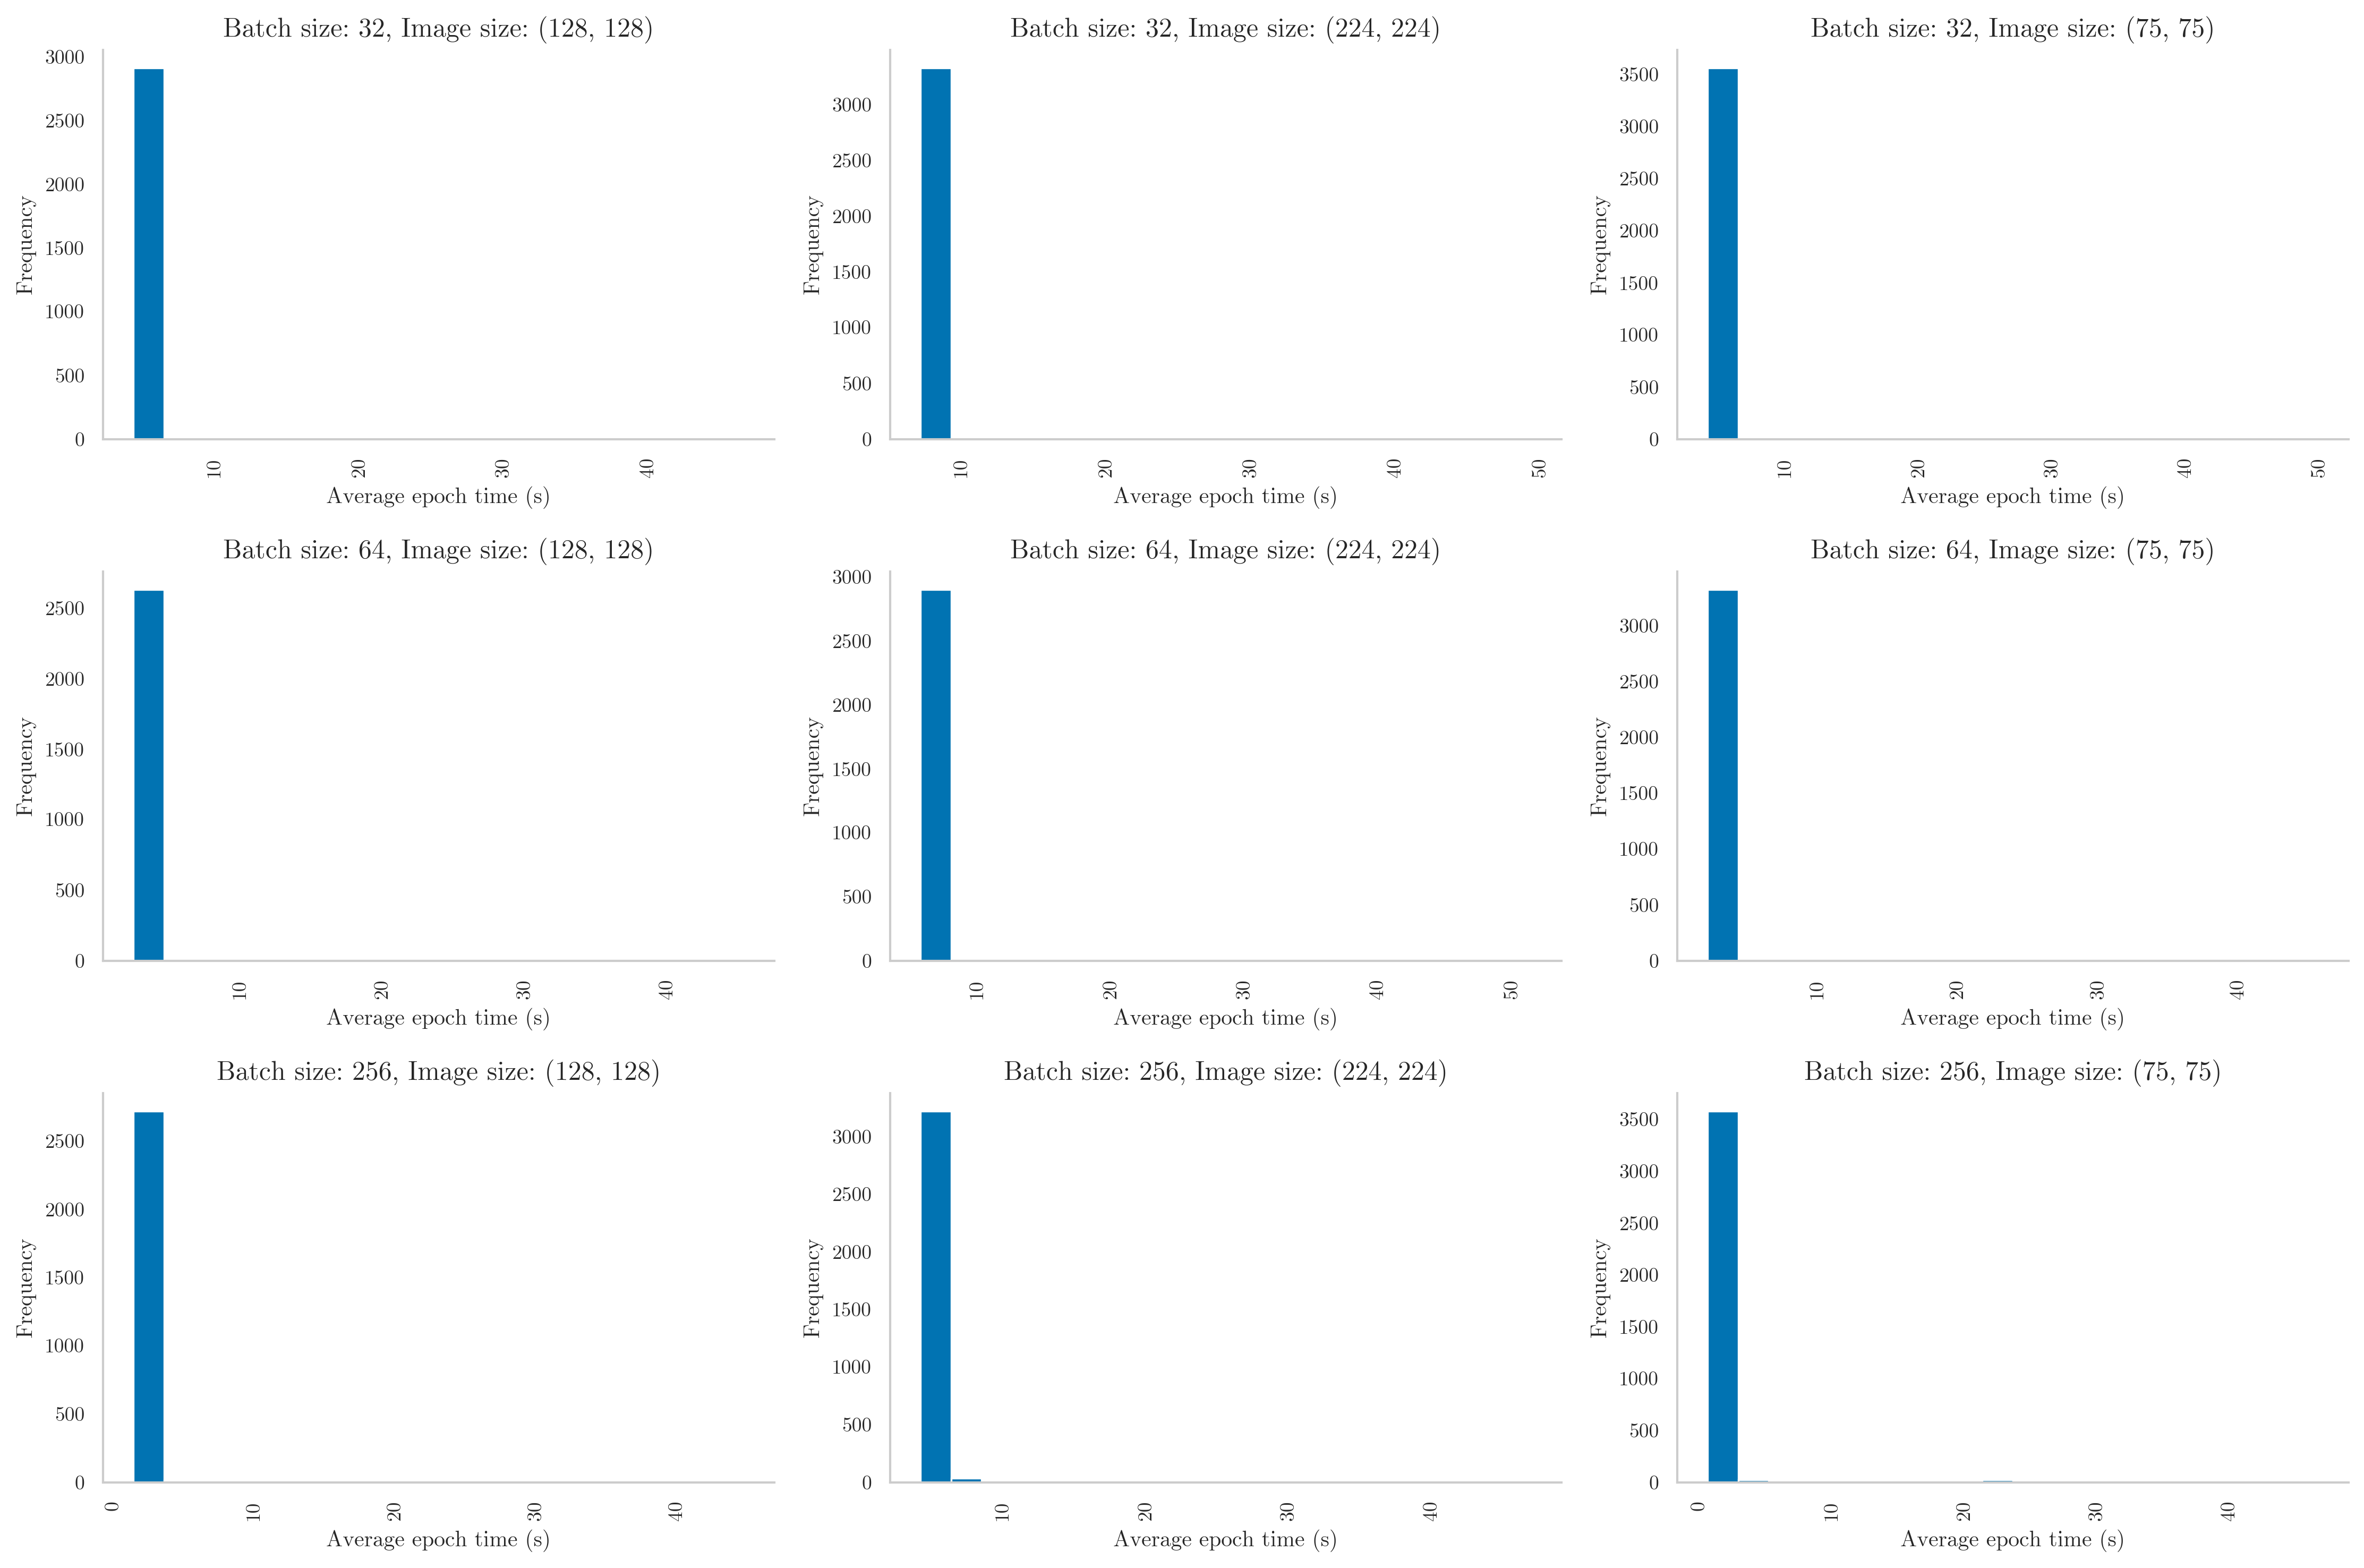

In [7]:
hist = epoch_energy_df.query("`training environment` == 'Server' and `dataset` == 'caltech101'").hist(
    column="duration (s)", by=["dataset", "batch size", "image size"], bins=20, figsize=(15, 10), layout=(3, 3)
)
for ax in hist.flatten():
    old_title = ax.get_title()
    if old_title == "":
        continue
    # ax.set_xlabel("Log$_{10}$(Average epoch time) (s)")
    ax.set_xlabel("Average epoch time (s)")
    ax.set_ylabel("Frequency")
    _, batch, input_size0, input_size1 = old_title.split(", ")
    ax.set_title(f"Batch size: {batch}, Image size: {input_size0}, {input_size1[:-1]}")

#### Histogram of epoch duration for the Caltech101 dataset in the Desktop ML Engineer environment


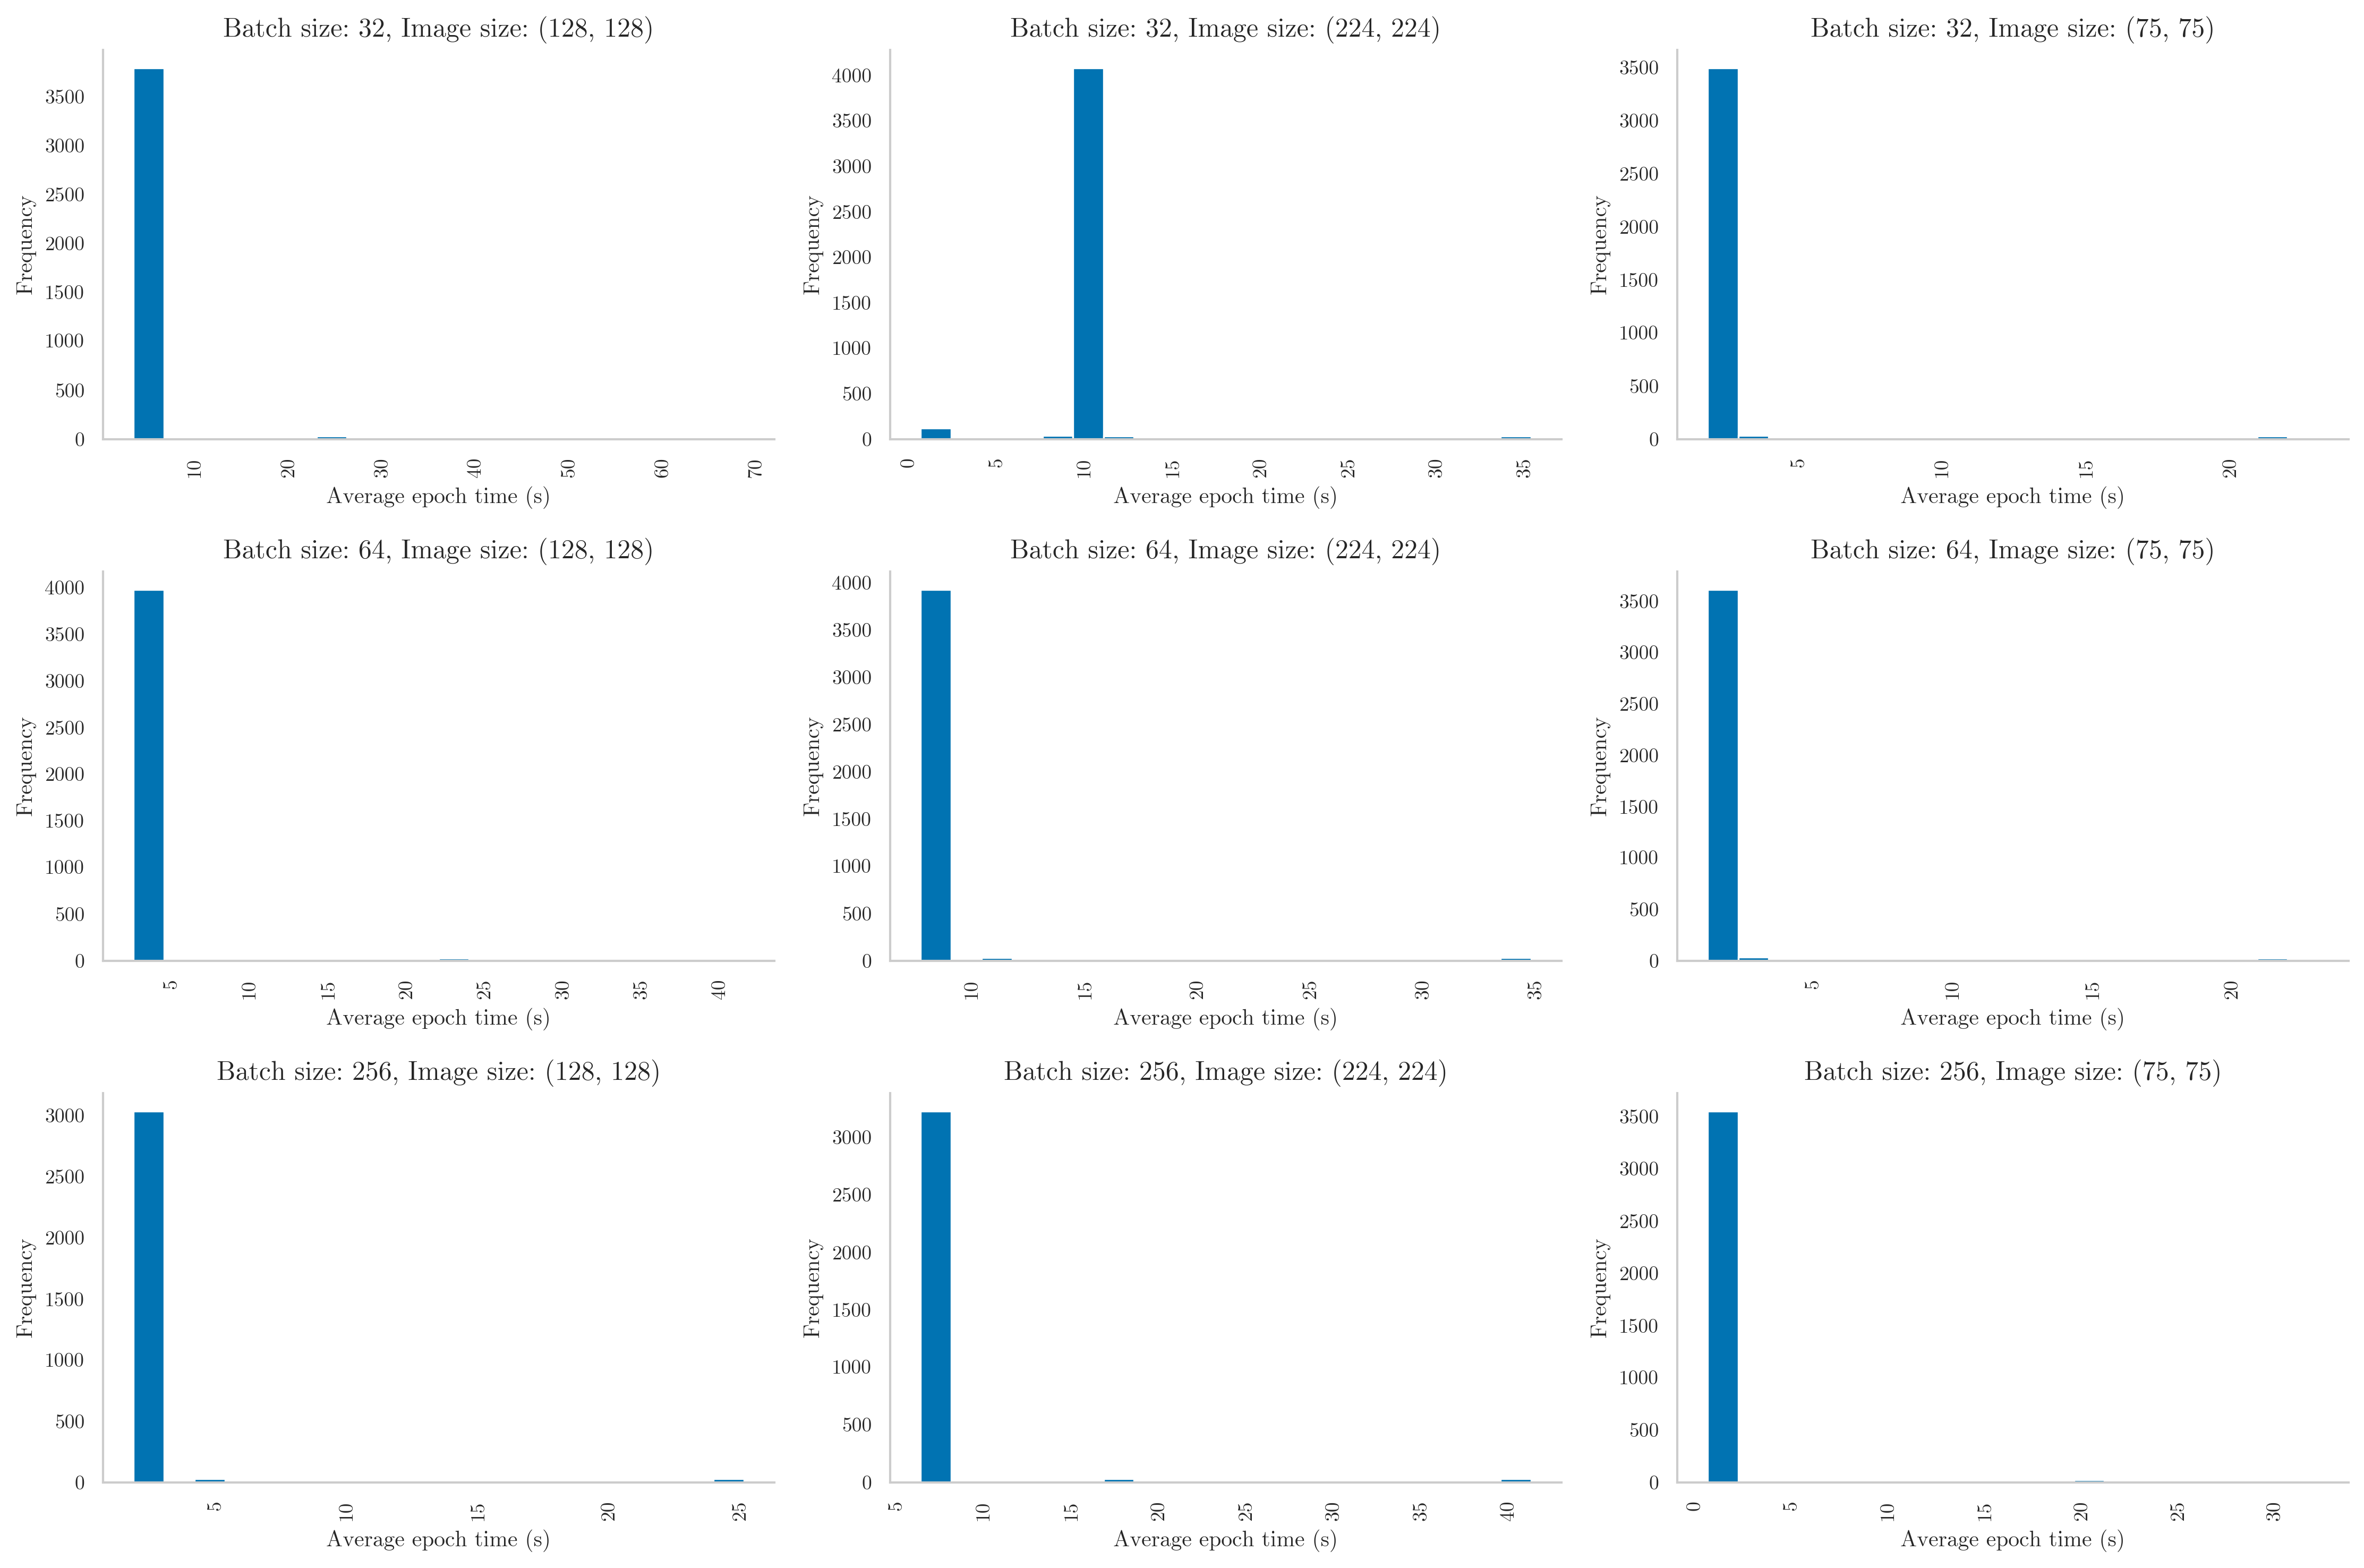

In [8]:
hist = epoch_energy_df.query("`training environment` == 'Desktop ML' and `dataset` == 'caltech101'").hist(
    column="duration (s)", by=["dataset", "batch size", "image size"], bins=20, figsize=(15, 10), layout=(3, 3)
)
for ax in hist.flatten():
    old_title = ax.get_title()
    if old_title == "":
        continue
    # ax.set_xlabel("Log$_{10}$(Average epoch time) (s)")
    ax.set_xlabel("Average epoch time (s)")
    ax.set_ylabel("Frequency")
    _, batch, input_size0, input_size1 = old_title.split(", ")
    ax.set_title(f"Batch size: {batch}, Image size: {input_size0}, {input_size1[:-1]}")

### Histogram of epoch duration for the Stanford Dogs dataset in the Server


/tmp/ipykernel_16536/2011981811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hist_data["label"] = "Batch: " + hist_data["batch size"].astype(str) + ", Input: " + hist_data["image size"].astype(str)


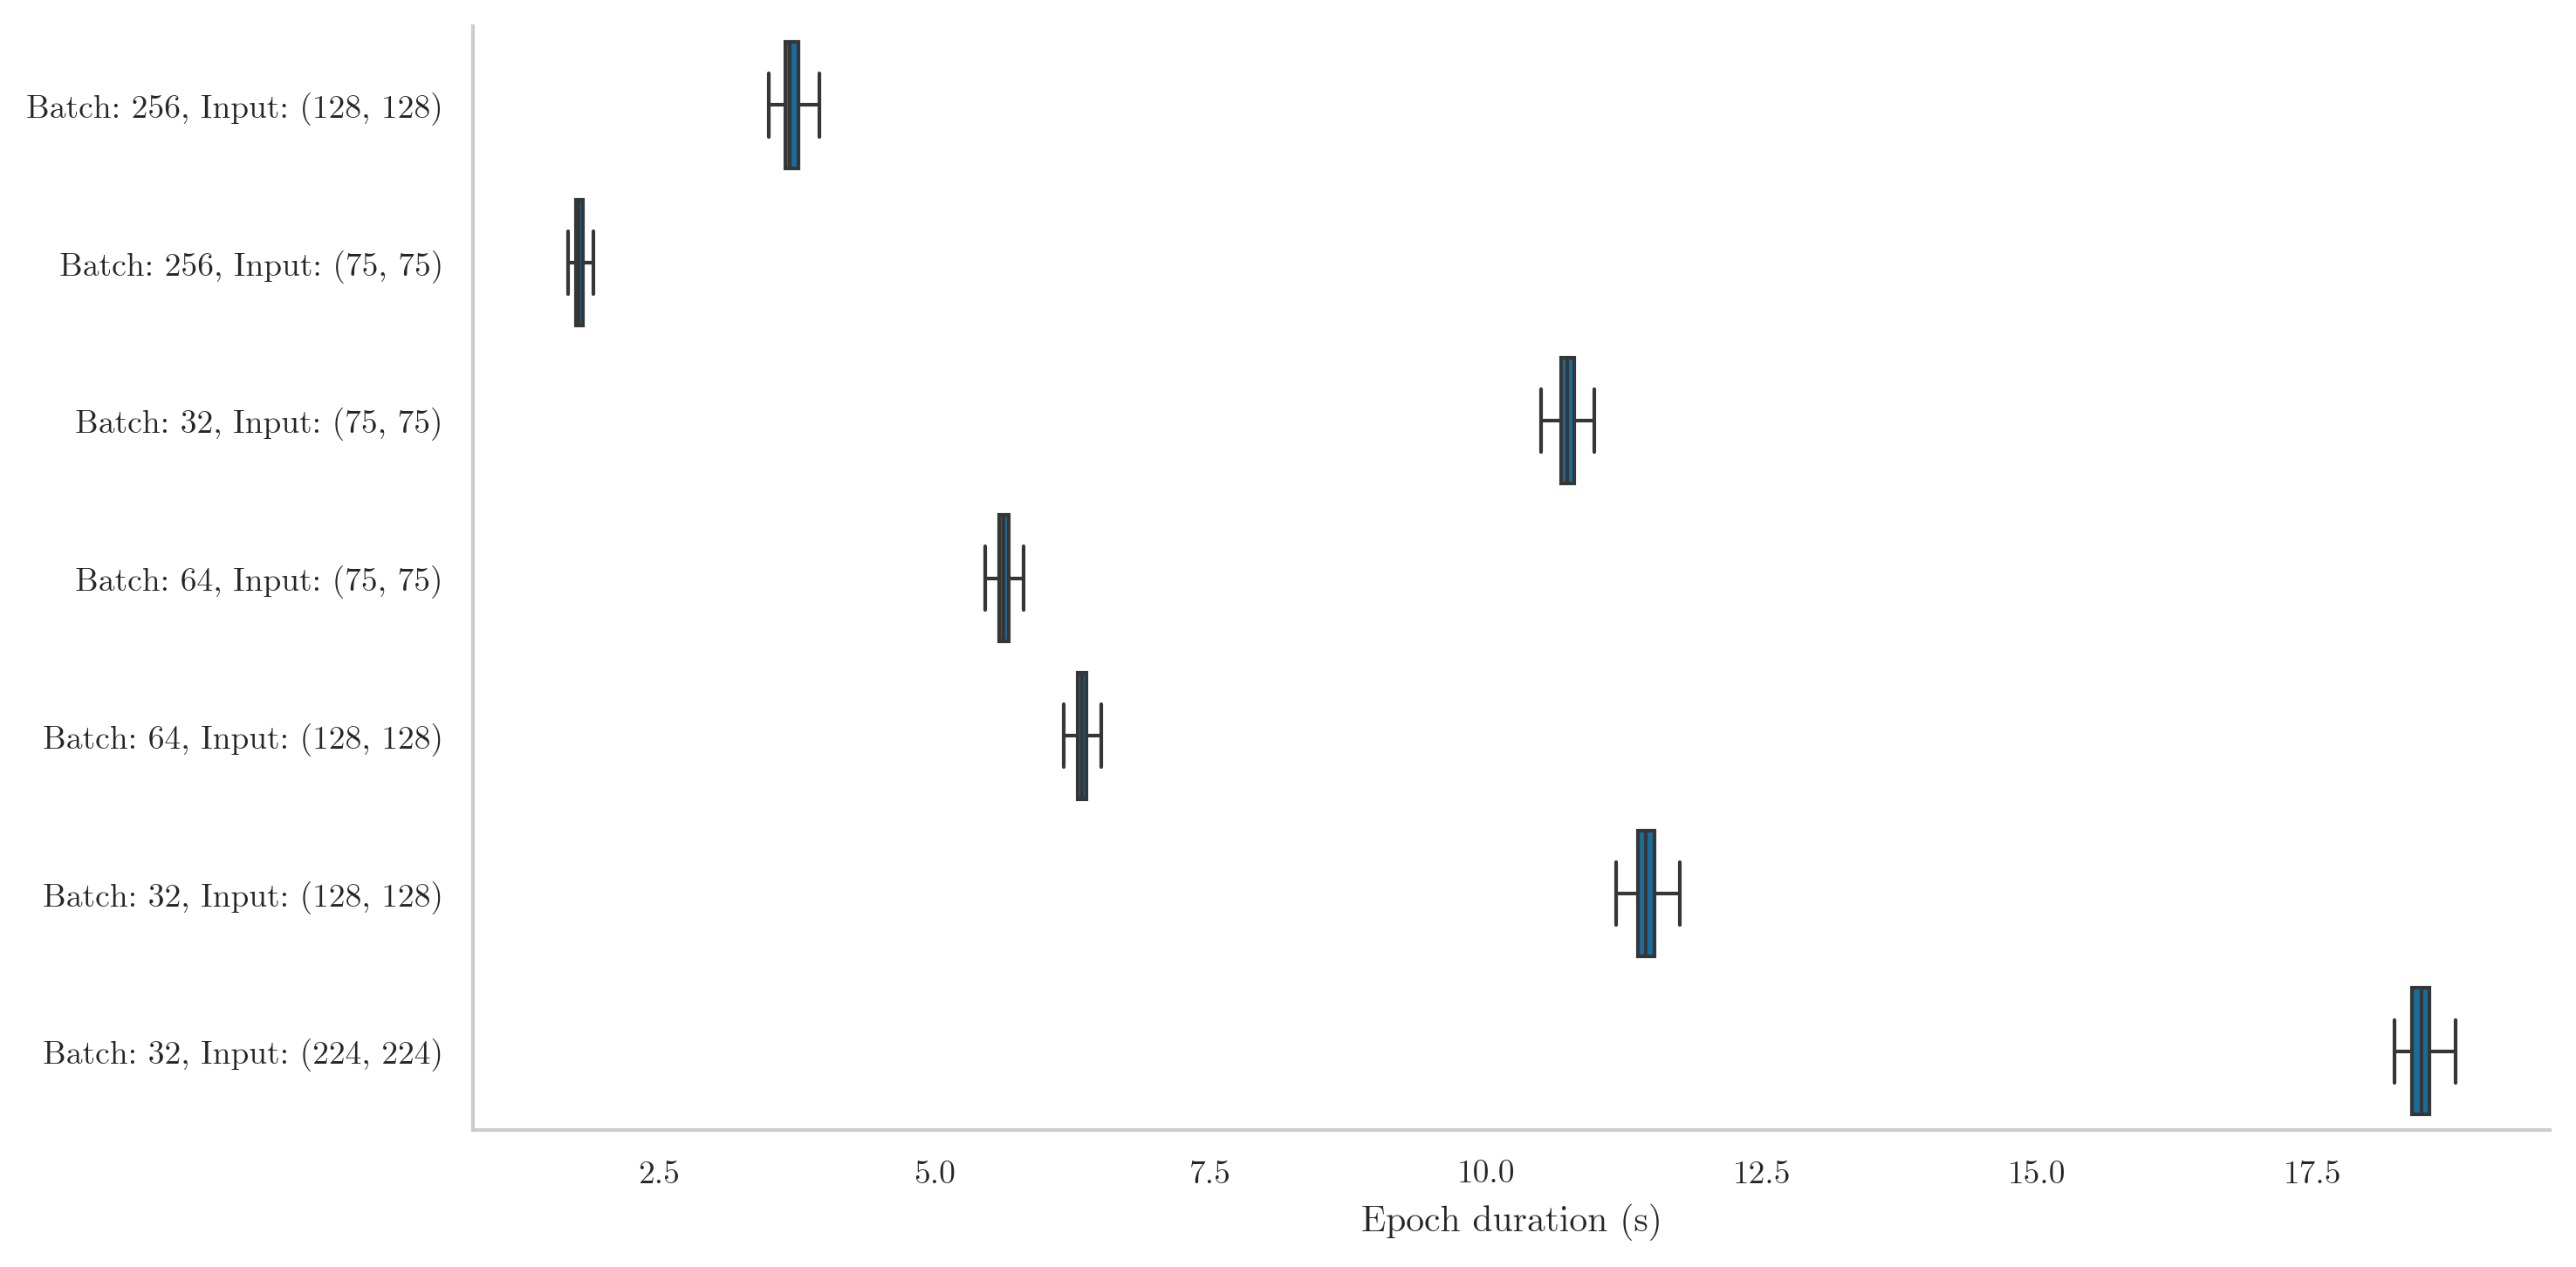

In [9]:
hist_data = epoch_energy_df.query("`training environment` == 'Server' and `dataset` == 'stanford_dogs' and epoch >= 10")
hist_data["label"] = "Batch: " + hist_data["batch size"].astype(str) + ", Input: " + hist_data["image size"].astype(str)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.boxplot(data=hist_data, y="label", x="duration (s)", ax=ax, showfliers=False)
ax.set_ylabel("")
ax.set_xlabel("Epoch duration (s)")

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"epoch-time-boxplot-server-stanford-dogs.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

#### Histogram of epoch duration for the Stanford Dogs dataset in the Desktop ML Engineer environment


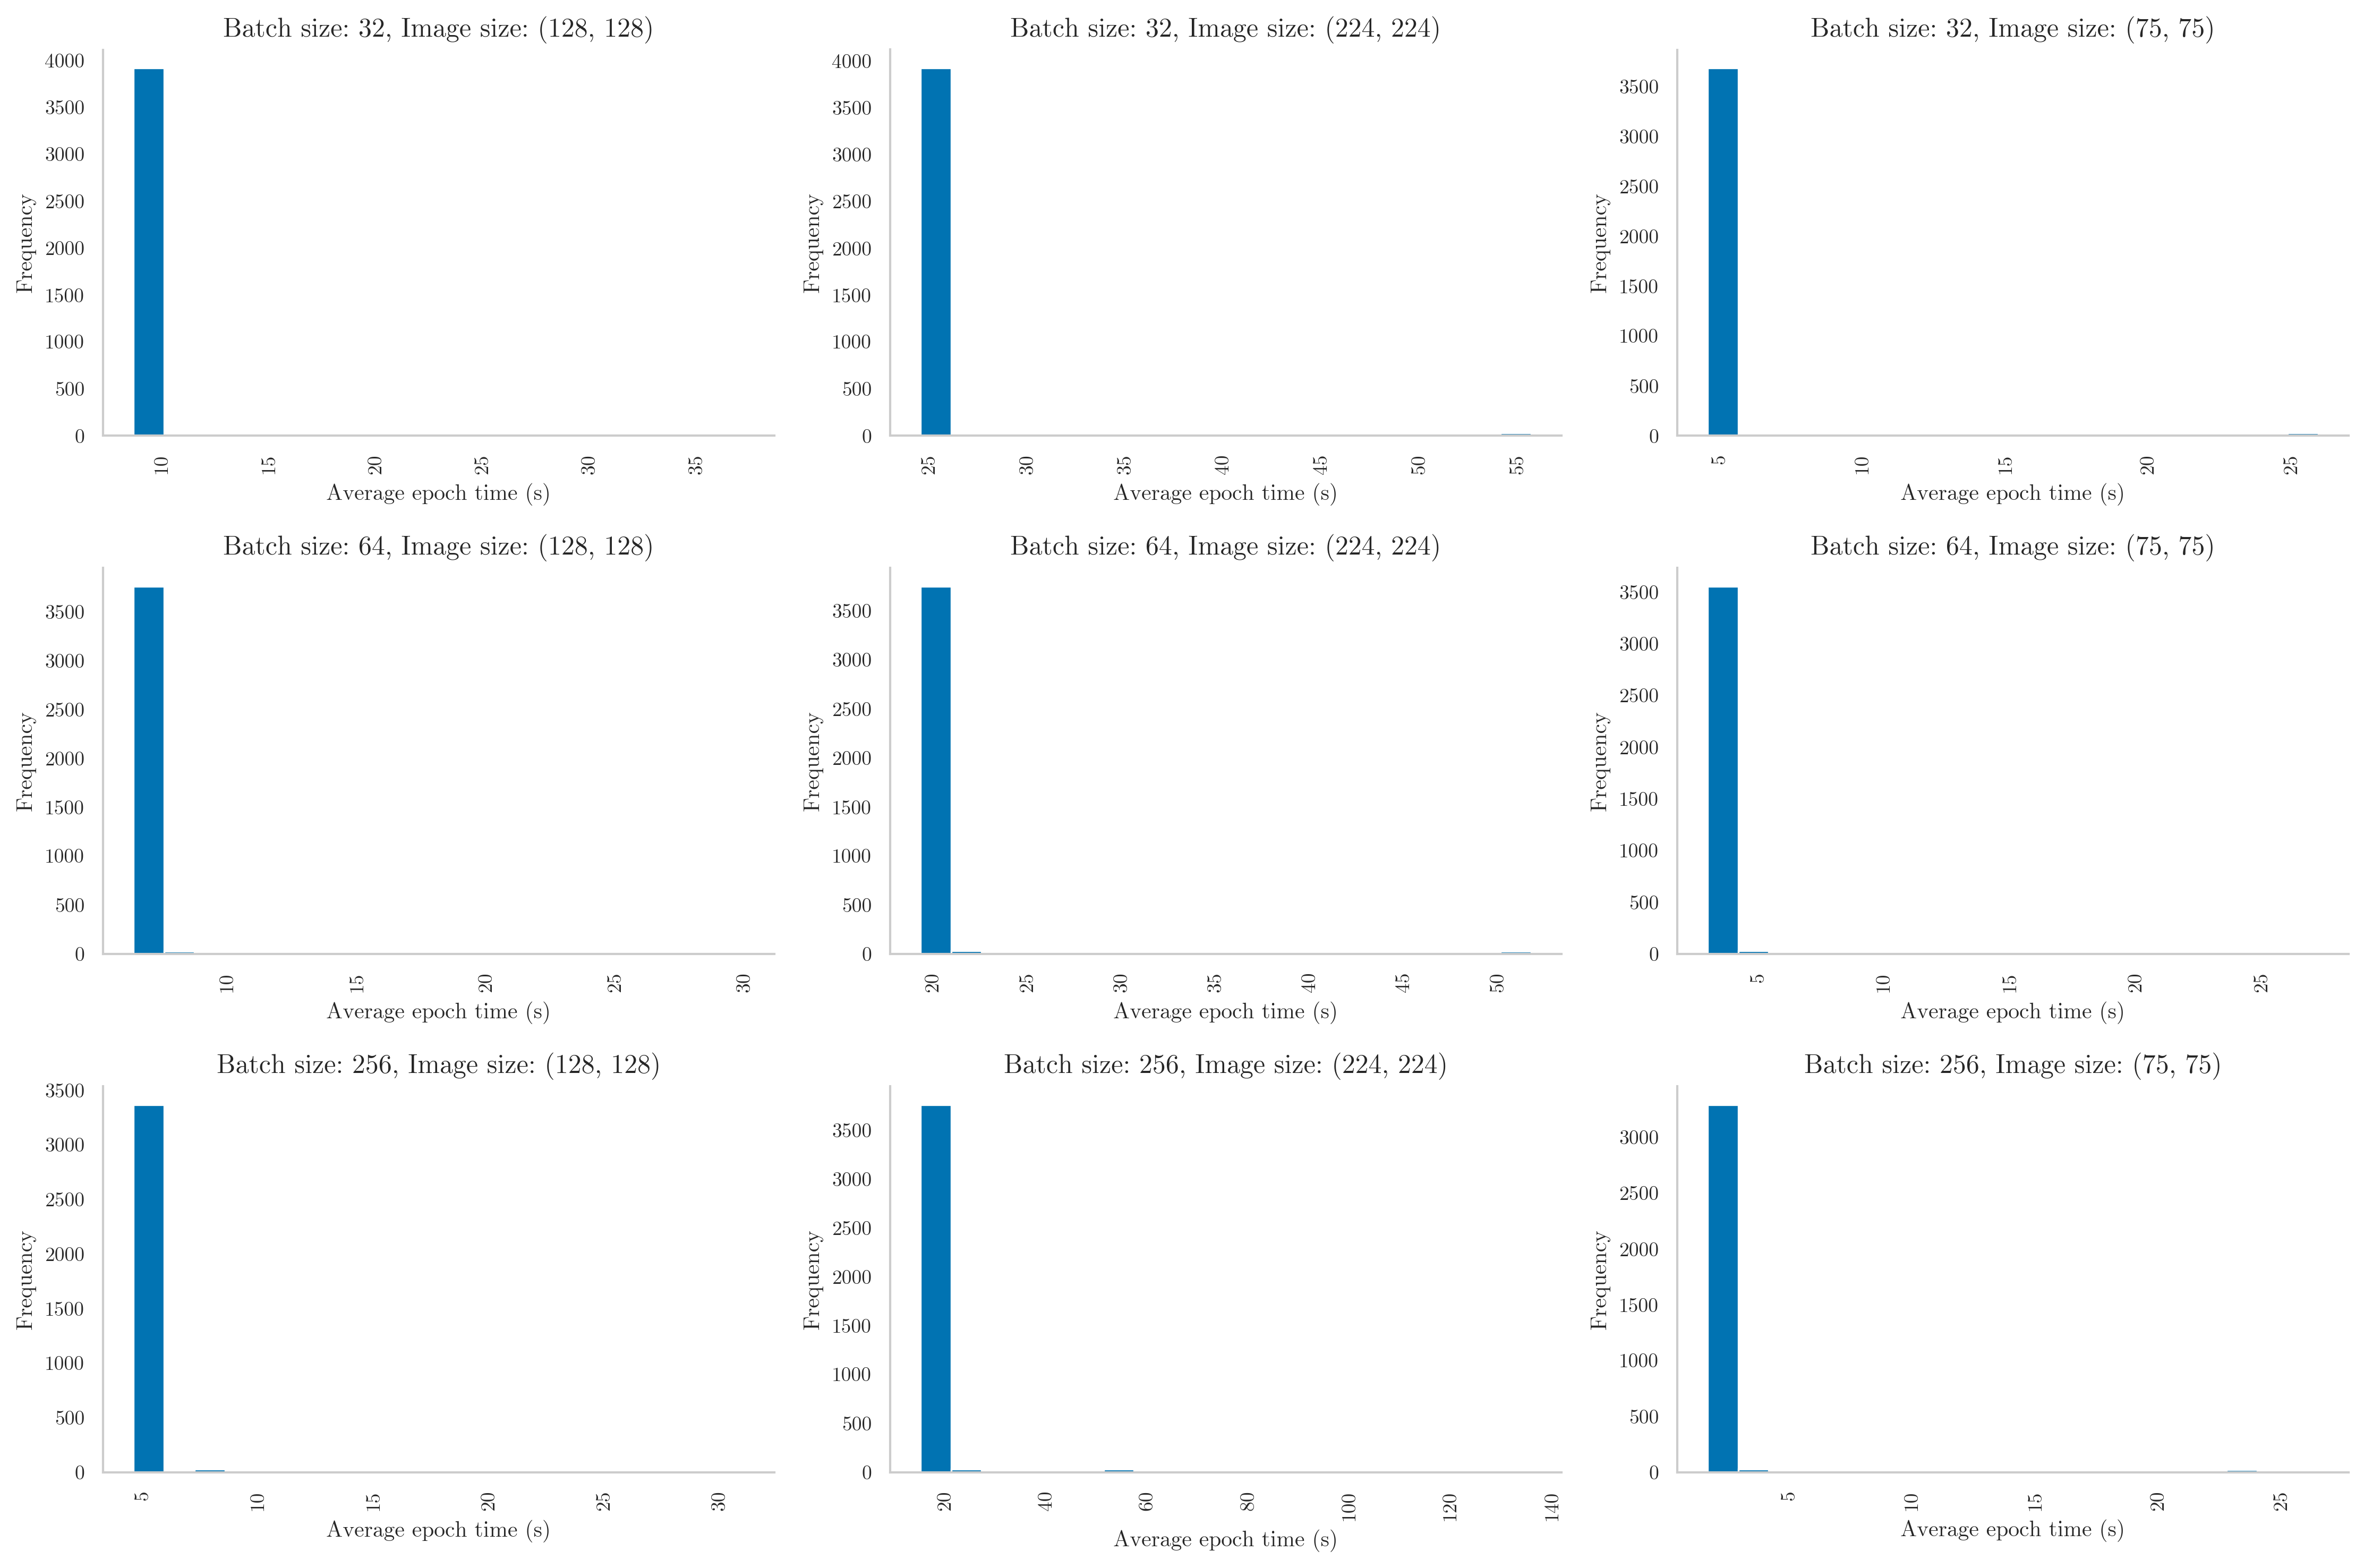

In [10]:
hist = epoch_energy_df.query("`training environment` == 'Desktop ML' and `dataset` == 'stanford_dogs'").hist(
    column="duration (s)", by=["dataset", "batch size", "image size"], bins=20, figsize=(15, 10), layout=(3, 3)
)
for ax in hist.flatten():
    old_title = ax.get_title()
    if old_title == "":
        continue
    # ax.set_xlabel("Log$_{10}$(Average epoch time) (s)")
    ax.set_xlabel("Average epoch time (s)")
    ax.set_ylabel("Frequency")
    _, batch, input_size0, input_size1 = old_title.split(", ")
    ax.set_title(f"Batch size: {batch}, Image size: {input_size0}, {input_size1[:-1]}")

In [28]:
from numpy import quantile

epoch_energy_df_no_outliers = (
    epoch_energy_df.query("dataset != 'chesslive-occupancy'")
    .groupby(["training environment", "dataset", "batch size", "image size"])
    .apply(
        lambda x: x.assign(
            q1=quantile(x["duration (s)"], 0.25),
            q3=quantile(x["duration (s)"], 0.75),
            IQR=quantile(x["duration (s)"], 0.75) - quantile(x["duration (s)"], 0.25),
            is_outlier=(
                (
                    x["duration (s)"]
                    < quantile(x["duration (s)"], 0.25)
                    - 1.5 * (quantile(x["duration (s)"], 0.75) - quantile(x["duration (s)"], 0.25))
                )
                | (
                    x["duration (s)"]
                    > quantile(x["duration (s)"], 0.75)
                    + 1.5 * (quantile(x["duration (s)"], 0.75) - quantile(x["duration (s)"], 0.25))
                )
            ),
        )
    )
)

epoch_energy_df_no_outliers = epoch_energy_df_no_outliers.query("is_outlier == False").reset_index(drop=True)

/tmp/ipykernel_16536/2928454428.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


If we look at the at the actual values. We see that most of the maximum differences are below 5 seconds when excluding the first epoch. Moreover, independently of the dataset, batch size and image size, 75% of the epochs have a duration difference below 1 second.


In [29]:
epoch_energy_df_no_outliers.query("`dataset` != 'chesslive-occupancy' and `epoch` > 0").groupby(
    ["training environment", "dataset", "batch size", "image size"]
)["duration (s)"].agg(np.ptp)

training environment  dataset        batch size  image size
Desktop ML            caltech101     32          (128, 128)    0.283000
                                                 (224, 224)    0.832000
                                                 (75, 75)      0.282000
                                     64          (128, 128)    0.227000
                                                 (224, 224)    0.235000
                                                 (75, 75)      0.176000
                                     256         (128, 128)    0.190000
                                                 (224, 224)    0.171000
                                                 (75, 75)      0.062250
                      stanford_dogs  32          (128, 128)    0.414000
                                                 (224, 224)    0.768000
                                                 (75, 75)      0.587000
                                     64          (128, 128)    0.310000
    

In [30]:
epoch_energy_df_no_outliers.query("`dataset` != 'chesslive-occupancy'").groupby(
    ["training environment", "dataset", "batch size", "image size"]
)["duration (s)"].describe()

count       mean  \
training environment dataset       batch size image size                       
Desktop ML           caltech101    32         (128, 128)   3596.0   3.621648   
                                              (224, 224)   3990.0   9.745617   
                                              (75, 75)     3401.0   2.072869   
                                   64         (128, 128)   3735.0   2.697070   
                                              (224, 224)   3482.0   8.009472   
                                              (75, 75)     3438.0   1.346910   
                                   256        (128, 128)   2565.0   2.059272   
                                              (224, 224)   3113.0   6.485234   
                                              (75, 75)     3392.0   0.708400   
                     stanford_dogs 32         (128, 128)   3629.0   9.132616   
                                              (224, 224)   3806.0  25.065179   
                                              (75, 75)     3631.0   5.053477   
                                   64         (128, 128)   3631.0   6.580090   
                                              (224, 224)   3201.0  19.968476   
                                              (75, 75)     3406.0   3.226863   
                                   256        (128, 128)   3187.0   4.741725   
                                              (224, 224)   3276.0  15.786664   
                                              (75, 75)     3141.0   1.808093   
Server               caltech101    32         (128, 128)   2728.0   4.586347   
                                              (224, 224)   3092.0   7.374328   
                                              (75, 75)     3215.0   4.414117   
                                   64         (128, 128)   2460.0   2.637166   
                                              (224, 224)   2647.0   5.858271   
                                              (75, 75)     3101.0   2.311986   
                                   256        (128, 128)   2489.0   1.550609   
                                              (224, 224)   2999.0   4.390487   
                                              (75, 75)     3356.0   0.741020   
                     stanford_dogs 32         (128, 128)   3068.0  11.454003   
                                              (224, 224)    287.0  18.479632   
                                              (75, 75)     2865.0  10.741037   
                                   64         (128, 128)   3071.0   6.332129   
                                              (75, 75)     2783.0   5.625657   
                                   256        (128, 128)  12849.0   3.701672   
                                              (75, 75)     2559.0   1.770569   

                                                               std        min  \
training environment dataset       batch size image size                        
Desktop ML           caltech101    32         (128, 128)  0.052664   3.484000   
                                              (224, 224)  0.154981   9.346000   
                                              (75, 75)    0.049496   1.934000   
                                   64         (128, 128)  0.040919   2.588000   
                                              (224, 224)  0.038930   7.892000   
                                              (75, 75)    0.030458   1.261000   
                                   256        (128, 128)  0.033261   1.963000   
                                              (224, 224)  0.029099   6.402000   
                                              (75, 75)    0.011105   0.677607   
                     stanford_dogs 32         (128, 128)  0.074510   8.924000   
                                              (224, 224)  0.139091  24.687000   
                                              (75, 75)    0.105539   4.760000   
                                   64        

## Power profile analysis


### When does power consumption stabilize?


To detect when the power consumption stabilizes, we will apply semanting segmentation on the power profiles of each run.
To this end, we will compute the Matrix Profile (MP) of each run setting the window size $m = 10$.

We will use the [stumpy](https://stumpy.readthedocs.io/en/latest/) library to compute the MP and to apply semantic segmentation.

First, we compute the MP of each run. Then, we use the MP to compute the corrected arc curve (CAC).
From the CAC, we select the point with the lowest value as the point where there is a change in the power consumption regime.
We will call this point the _stabilizing point_.
We will use this point to compute the time it took for the power consumption to stabilize and which epoch it corresponds to.

For this analysis we will use the runs from the Server enviroment using the InceptionV3 model, since are the ones where we have the actual epoch duration.


In [ ]:
m = 10
L = m
if not os.path.exists(DATA_DIR / "analysis" / "processed" / "regimes.gzip") or not os.path.exists(
    DATA_DIR / "analysis" / "processed" / "server_inception_mps.pkl"
):
    regimes_df, profiles = find_stabilizing_point(
        epoch_energy_df_no_outliers["run_id"].unique(), metrics, m, L, save=True
    )
    regimes_df["stabilizing epoch"] = regimes_df["stabilizing epoch"].astype(np.uint8)
else:
    regimes_df = pd.read_parquet(DATA_DIR / "analysis" / "processed" / "regimes.gzip")
    regimes_df["stabilizing epoch"] = regimes_df["stabilizing epoch"].astype(np.uint8)
    with open(DATA_DIR / "analysis" / "processed" / "server_inception_mps.pkl", "rb") as f:
        profiles = pickle.load(f)

 10%|█         | 103/1002 [01:40<11:08,  1.35it/s]

In [14]:
regimes_df = regimes_df.merge(
    aggregated_metrics[INDEPENDENT_VARIABLES + ["run_id"]], on="run_id", how="inner"
)  # Add independent variables to group results by batch size and image size
regimes_df.groupby(["dataset", "batch size", "image size"]).describe()

elapsed time              \
                                                 count        mean   
dataset             batch size image size                            
caltech101          32         (128, 128)         55.0   38.821836   
                               (224, 224)         56.0   32.159857   
                               (75, 75)           56.0   32.384589   
                    64         (128, 128)         53.0   32.217396   
                               (224, 224)         52.0   32.162731   
                               (75, 75)           55.0   36.561273   
                    256        (128, 128)         52.0   35.148000   
                               (224, 224)         57.0   38.662895   
                               (75, 75)           59.0   26.687915   
chesslive-occupancy 32         (128, 128)        362.0  813.593464   
stanford_dogs       32         (128, 128)         55.0   36.982327   
                               (224, 224)         33.0  831.018182   
                               (75, 75)           54.0  103.873537   
                    64         (128, 128)         55.0   36.181327   
                               (224, 224)         30.0  211.187767   
                               (75, 75)           55.0   34.558218   
                    256        (128, 128)        141.0   35.784723   
                               (224, 224)         31.0   49.013742   
                               (75, 75)           54.0   34.790963   

                                                                           \
                                                   std     min        25%   
dataset             batch size image size                                   
caltech101          32         (128, 128)    39.994648  30.032   30.03550   
                               (224, 224)     4.374608  15.008   30.03775   
                               (75, 75)       5.878145  30.032   30.04025   
                    64         (128, 128)     5.574392  30.031   30.03800   
                               (224, 224)     5.095539  30.031   30.04300   
                               (75, 75)      14.816499  30.033   30.04250   
                    256        (128, 128)    11.722133  30.031   30.04400   
                               (224, 224)    25.034170  30.030   30.03300   
                               (75, 75)      11.179905  15.009   21.01100   
chesslive-occupancy 32         (128, 128)  2027.103069  32.033  204.57975   
stanford_dogs       32         (128, 128)     9.465893  30.036   30.06400   
                               (224, 224)  1285.046814  30.044   30.10600   
                               (75, 75)     244.680075  30.034   30.04800   
                    64         (128, 128)     9.390452  30.044   30.04800   
                               (224, 224)   600.132624  30.044   37.06650   
                               (75, 75)       7.892083  30.043   30.04700   
                    256        (128, 128)     9.300251  22.058   30.05300   
                               (224, 224)     8.601195  30.047   47.07350   
                               (75, 75)       9.628255  30.032   30.04700   

                                                                            \
                                                50%         75%        max   
dataset             batch size image size                                    
caltech101          32         (128, 128)   30.0460    30.04900    260.396   
                               (224, 224)   31.0505    33.06100     47.063   
                               (75, 75)     30.0470    30.05050     53.066   
                    64         (128, 128)   30.0480    30.05600     59.096   
                               (224, 224)   30.0490    31.30075     51.069   
                               (75, 75)     30.0470    42.55250    117.174   
                    256        (128, 128)   30.0485    30.06975     83.124   
                          

Looking at the histogram of the time it took for the power consumption to stabilize, we can see that over 60% of the runs stabilized in less than a minute from the start of the run.


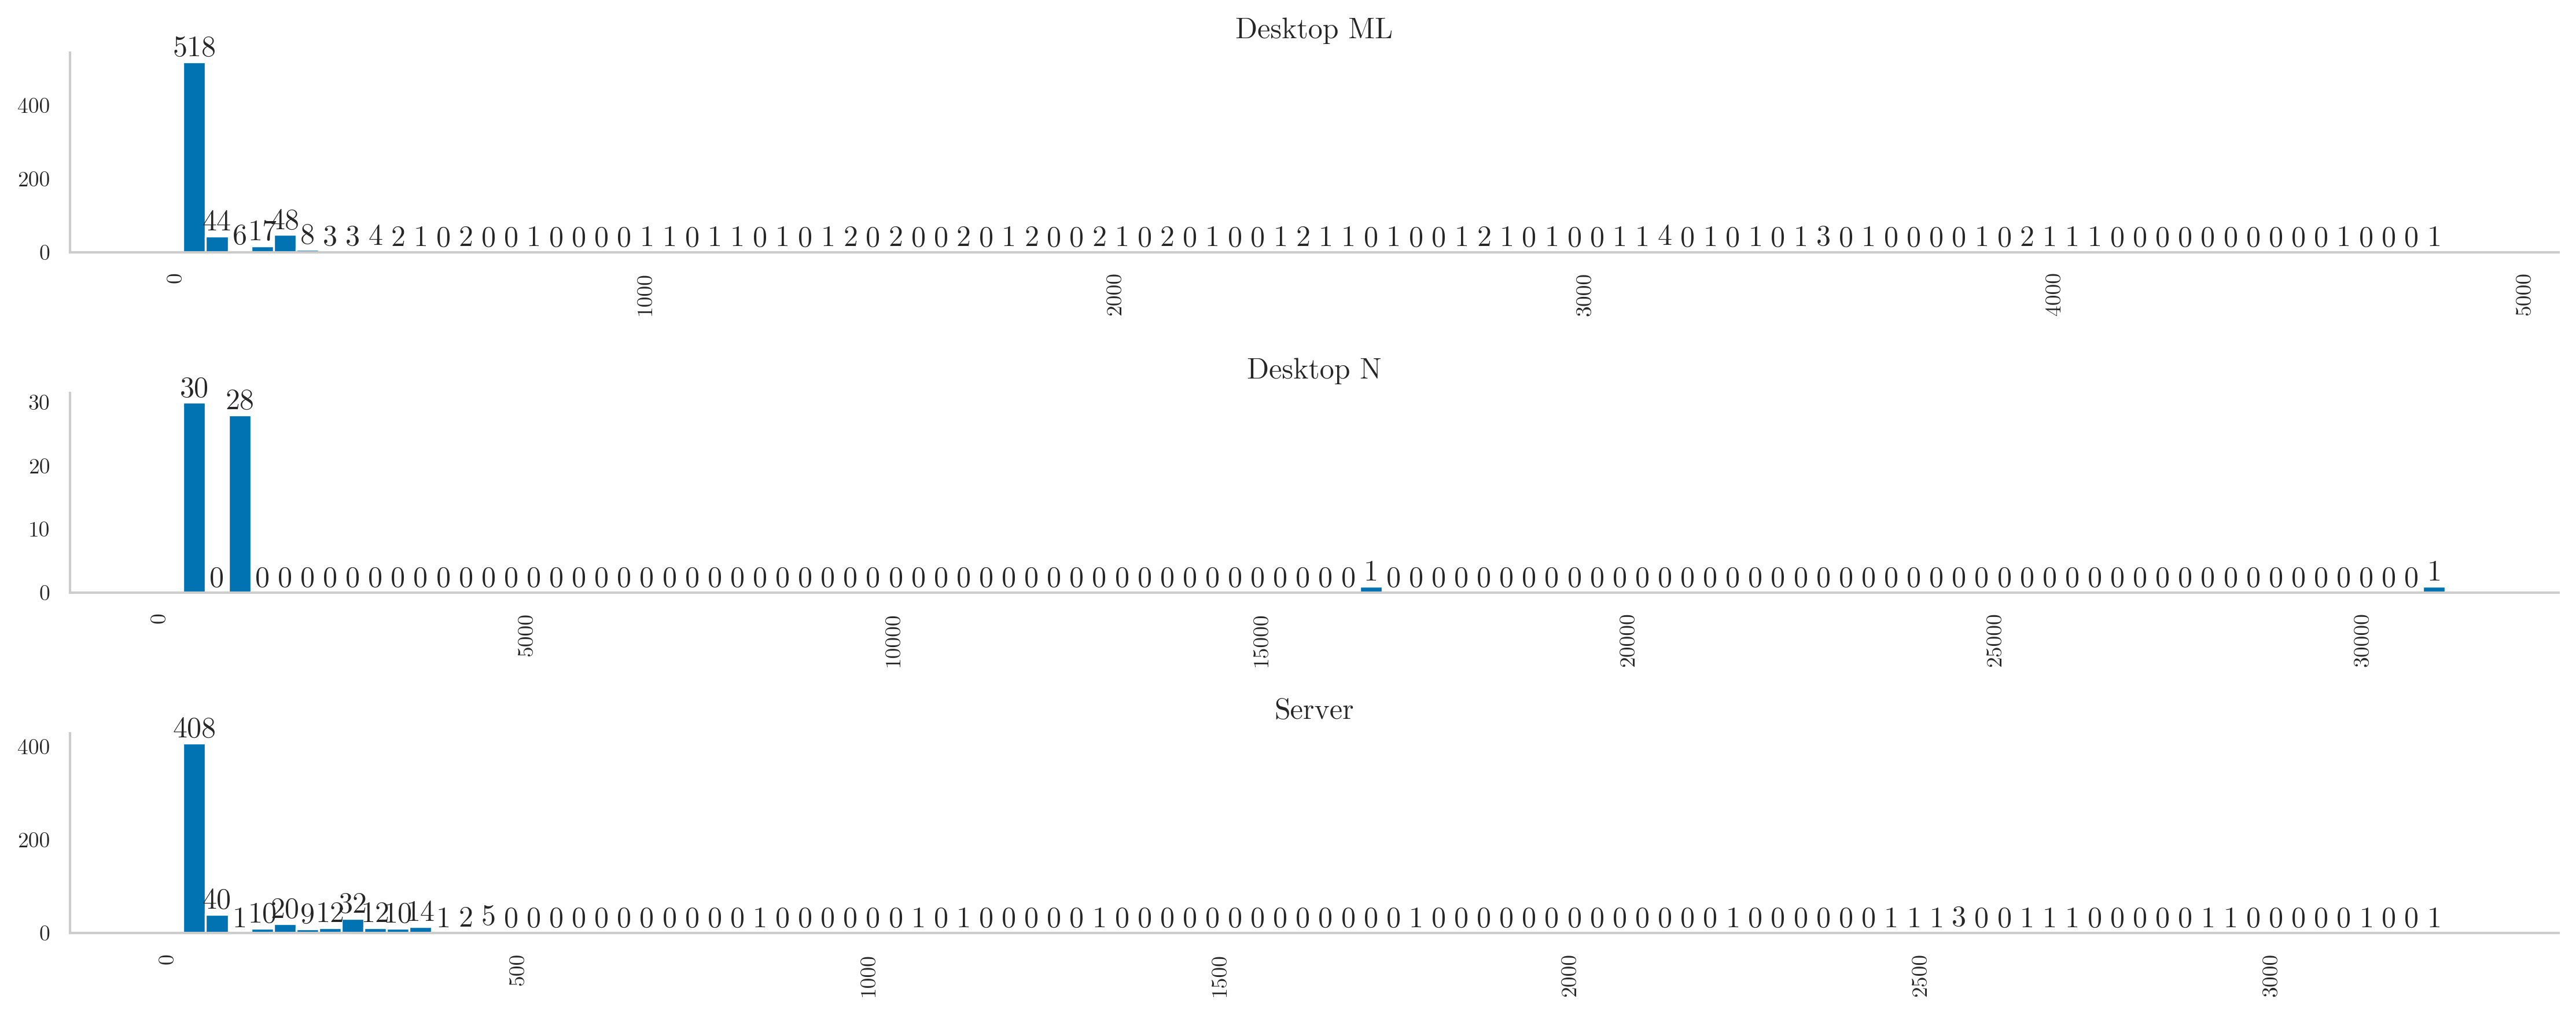

In [15]:
axs = regimes_df.hist(column="elapsed time", bins=100, figsize=(15, 6), by="training environment", layout=(3, 1))
for ax in axs.flatten():
    ax.bar_label(ax.containers[0], fmt="%d")
    training_env = ax.get_title()
    stop = regimes_df.query("`training environment` == @training_env")["elapsed time"].max() + 5

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"elapsed-time-histograms.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

Although the elapsed time offers an interesting view in the time it takes for the power consumption to stabilize, it is not reliable to compare runs with different hyperparameters like batch size and image size.

If we look at the epoch where the power consumption stabilized, we can see that more than 90% of the runs stabilized after the fourth epoch.
In fact, if we visually inspect those runs that stabilized after the fourth epoch, we can see there are a couple of false negatives in the the runs that stabilized during epoch 102 and 121.

Based on this results, we will assume that the power consumption stabilizes after the fourth epoch in general.


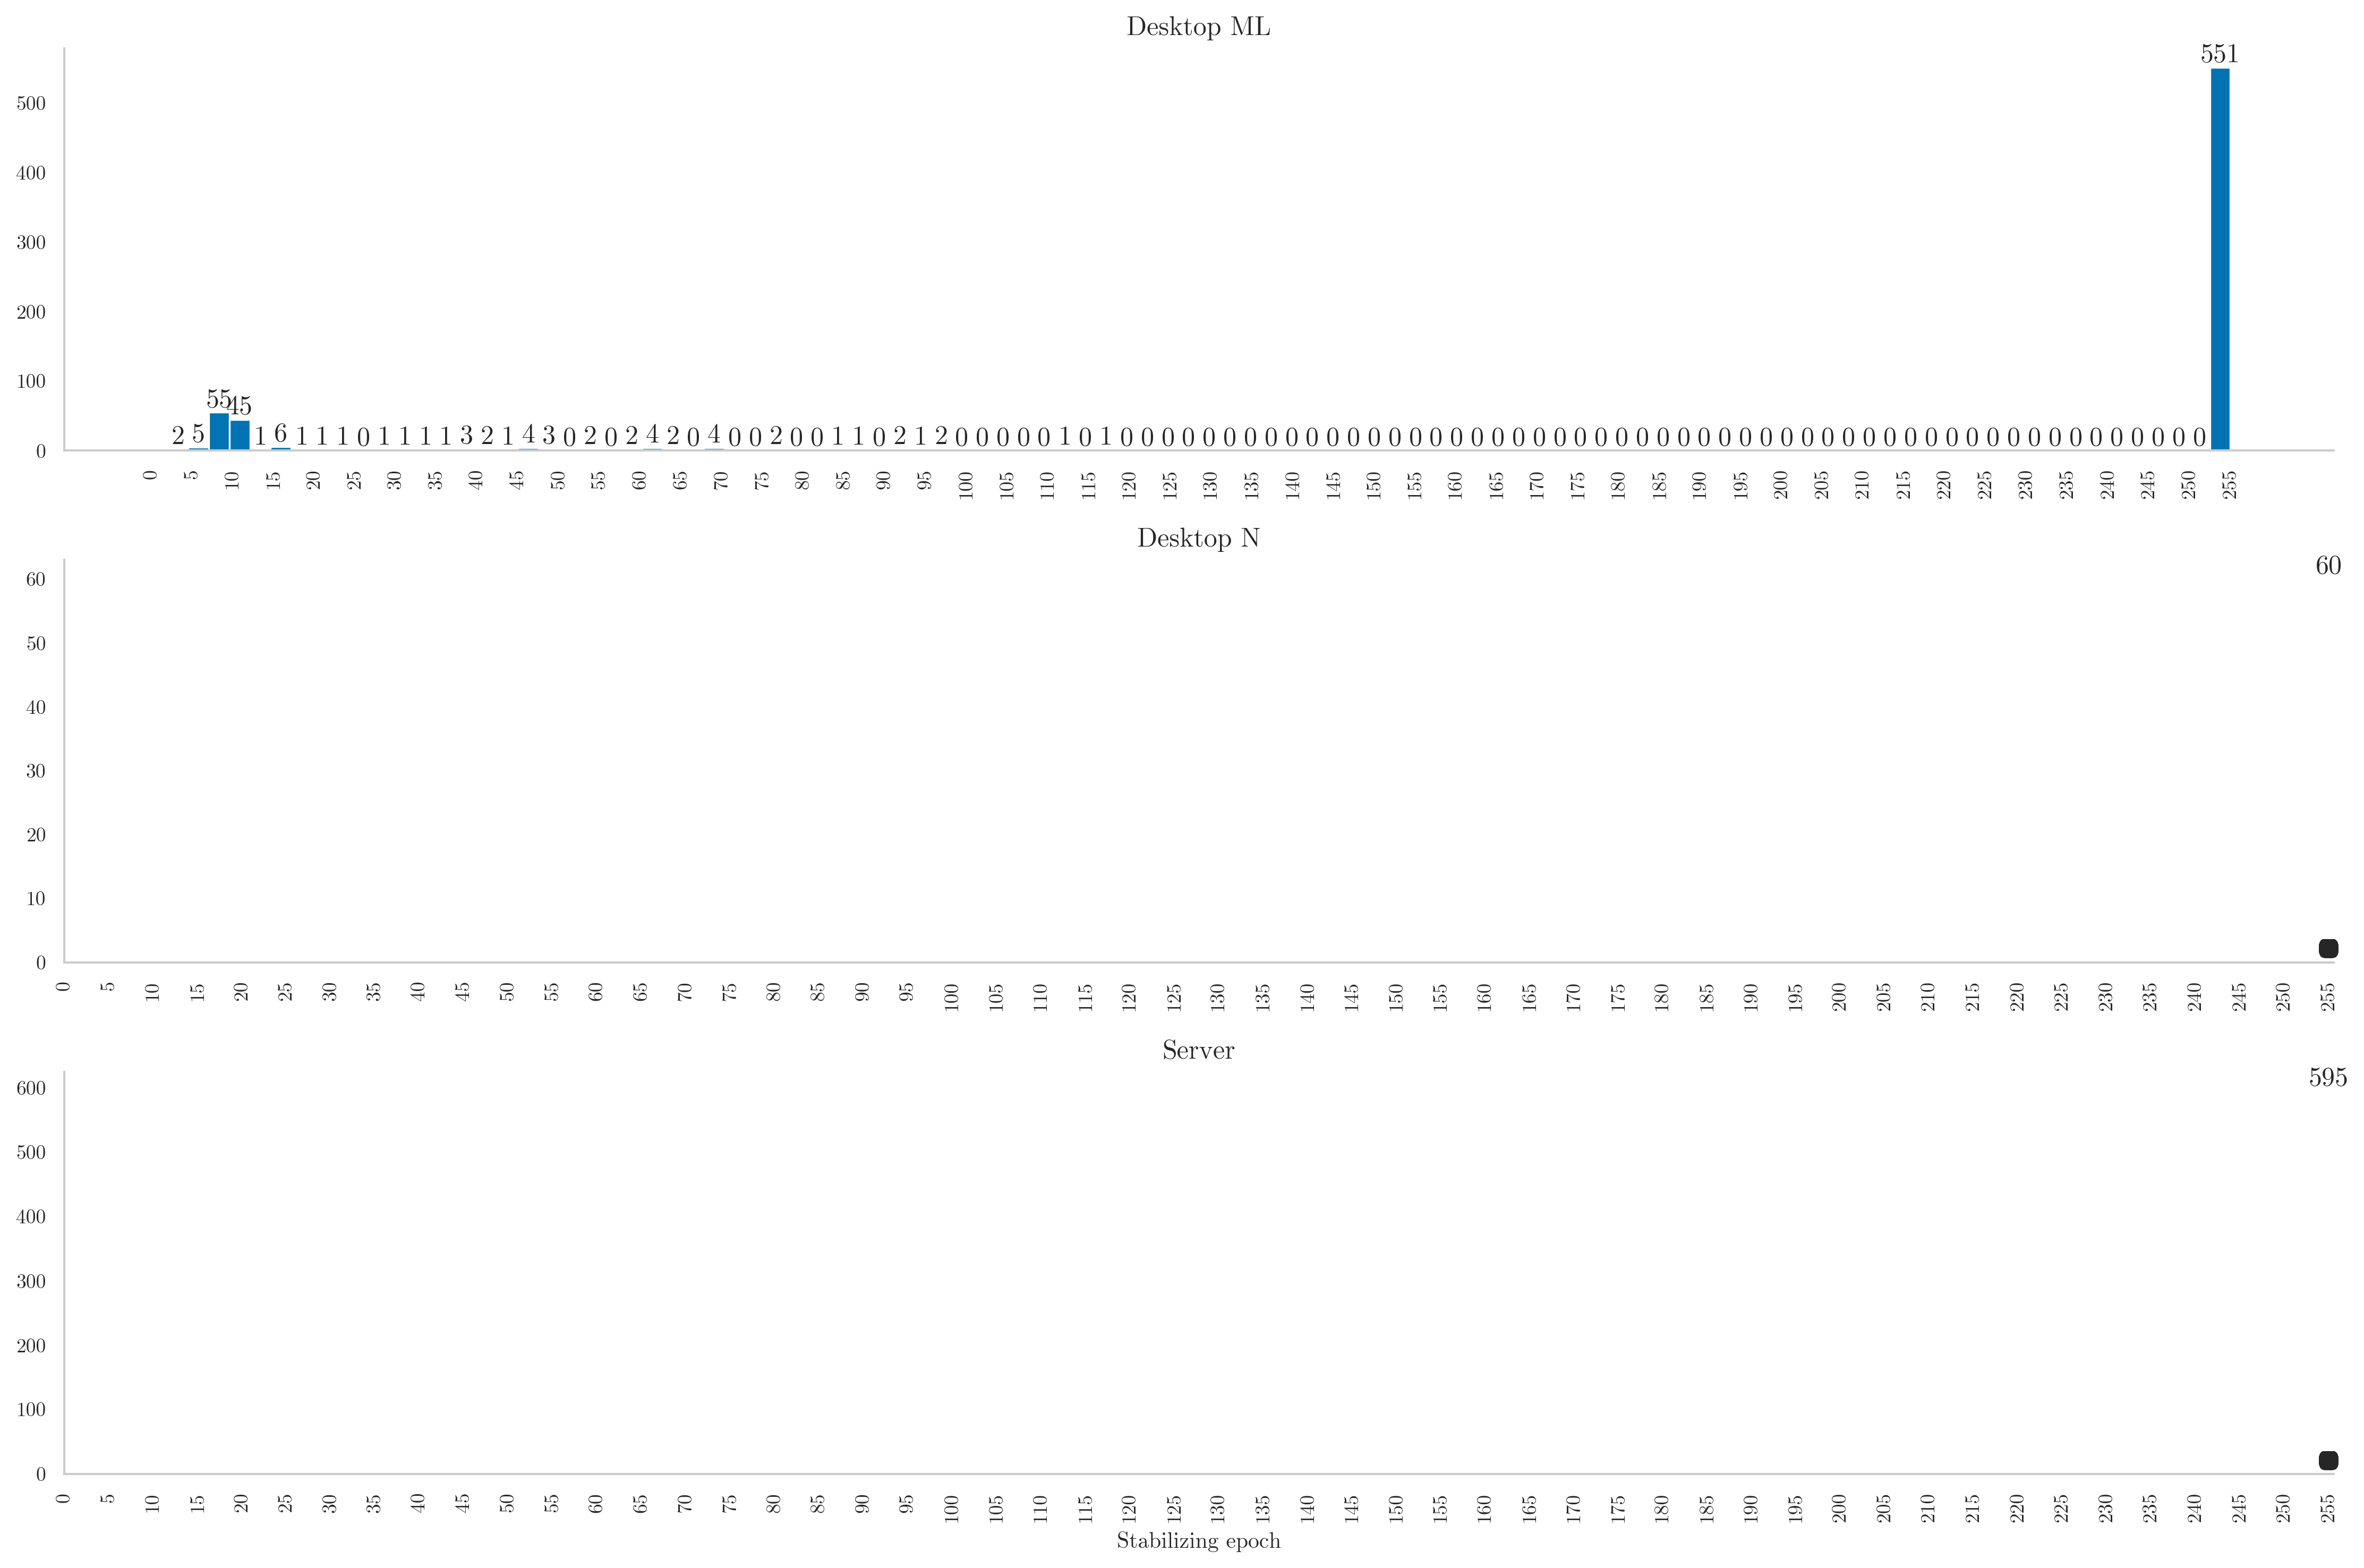

In [16]:
axs = regimes_df.hist(column="stabilizing epoch", bins=100, figsize=(15, 10), by="training environment", layout=(3, 1))
for ax in axs.flatten():
    ax.bar_label(ax.containers[0], fmt="%d")
    training_env = ax.get_title()
    stop = regimes_df.query("`training environment` == @training_env")["stabilizing epoch"].max() + 5
    ax.set_xticks(np.arange(0, stop, 5))

axs[-1].set_xlabel("Stabilizing epoch")

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"stabilizing-epoch-histograms.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

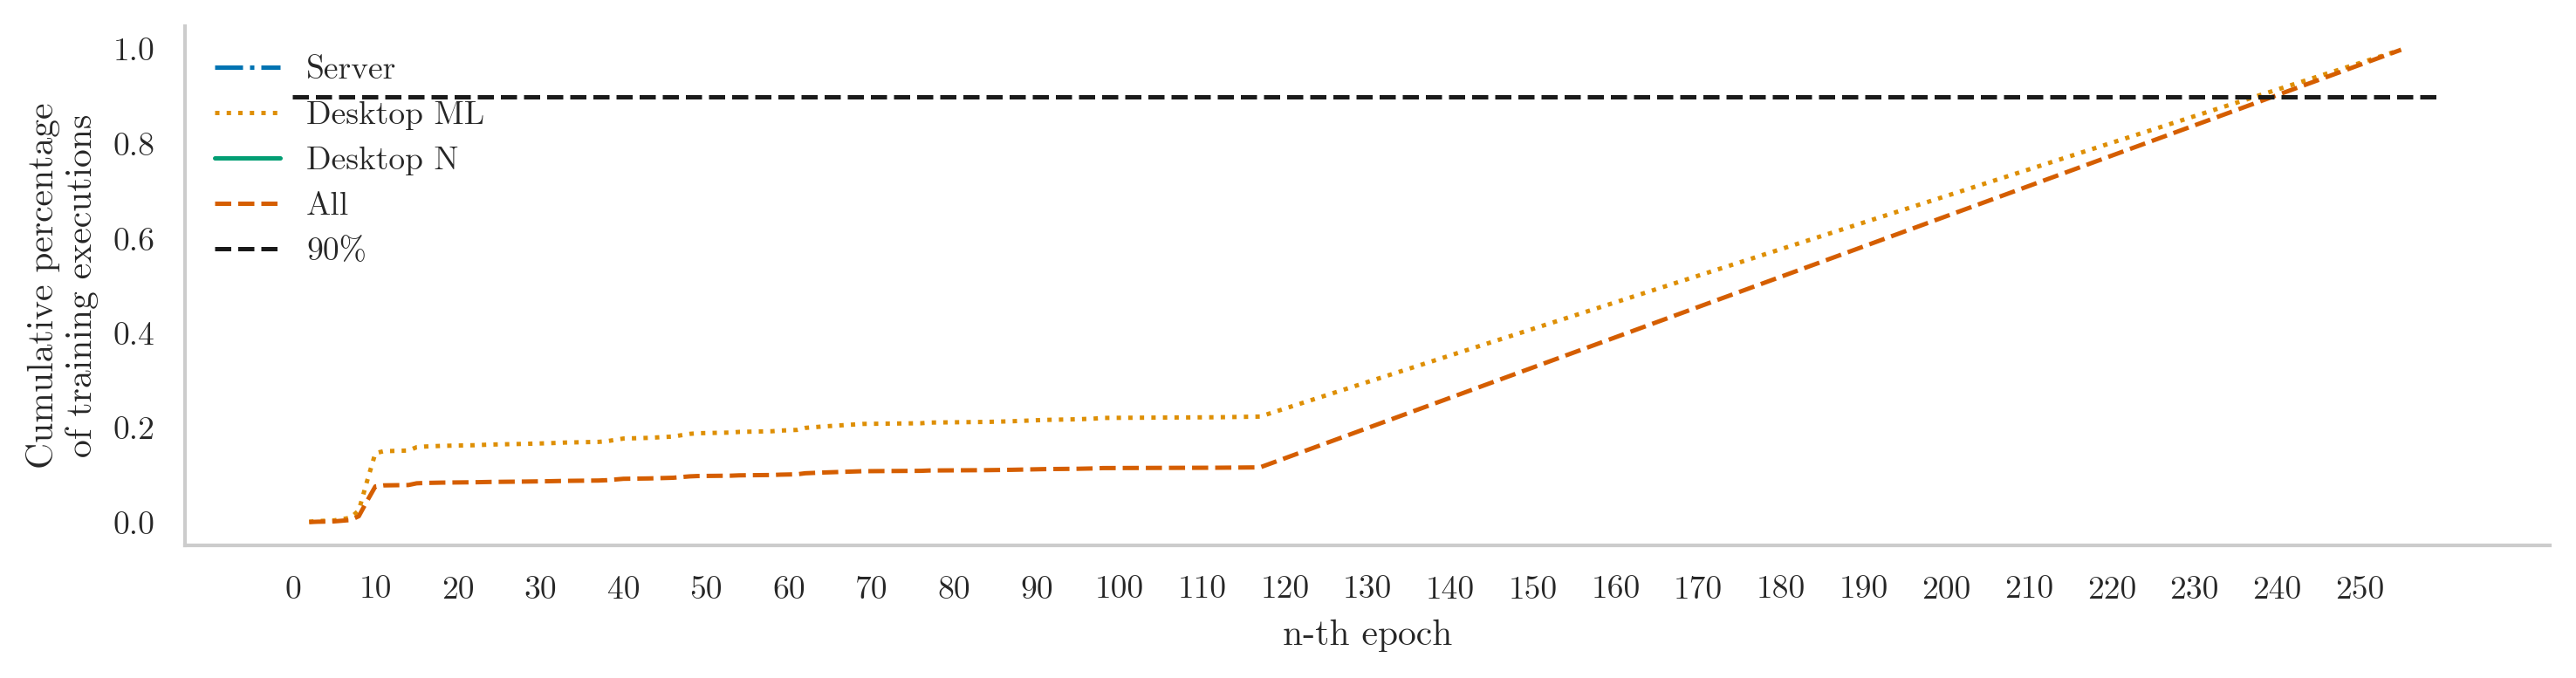

In [17]:
_, ax = plt.subplots(figsize=(10, 2.75))

linestyles = {
    "Desktop N": "solid",
    "Desktop ML": "dotted",
    "Server": "dashdot",
}

for training_env in regimes_df["training environment"].unique():
    regimes_df.query("`training environment` == @training_env")["stabilizing epoch"].value_counts(
        normalize=True
    ).sort_index().cumsum().plot(
        label=training_env,
        ax=ax,
        linestyle=linestyles[training_env],
    )
regimes_df["stabilizing epoch"].value_counts(normalize=True).sort_index().cumsum().plot(
    label="All", ax=ax, linestyle="dashed"
)
ax.hlines(0.9, 0, regimes_df["stabilizing epoch"].max() + 5, colors="k", linestyles="dashed", label="90%")
# ax.set_title("Accumulated percentage of runs that stabilize after the n-th epoch")
ax.set_ylabel("Cumulative percentage\nof training executions")
ax.set_xlabel("n-th epoch")
ax.set_xticks(np.arange(0, regimes_df["stabilizing epoch"].max() + 5, 10))
ax.legend()

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"stabilizing-epoch-cumulative-distribution.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

In [18]:
def plot_regime_change_example(stabilizing_epoch):
    example_run = regimes_df.query("`stabilizing epoch` == @stabilizing_epoch")["run_id"].sample(1).iloc[0]
    run = metrics.loc[metrics["run_id"] == example_run]
    epoch_ends = get_epoch_ends(run.iloc[0])
    regime_change = profiles[example_run]["regime_locations"][0]
    cac = profiles[example_run]["cac"]
    plot_regime_change(run, epoch_ends, cac, regime_change, stabilizing_epoch)

In [20]:
regimes_df

,run_id,elapsed time,stabilizing epoch,training environment,architecture,dataset,batch size,image size,total ram (GB)
0,00131e286bc847e4a0447e0944ba95b6,30.035,255,Server,inception_v3,caltech101,64,"(75, 75)",16.0
1,00880f78cd0f458ba2a0d2ea72c88805,234.276,255,Server,mobilenet_v2,chesslive-occupancy,32,"(128, 128)",16.0
2,009a03d661ed4b7cbe8a3cecd3e4fd3a,25.080,255,Server,inception_v3,caltech101,256,"(75, 75)",16.0
3,00bac5db17a74fe5bbfdbd9afb40652b,30.059,255,Desktop ML,inception_v3,caltech101,64,"(75, 75)",32.0
4,00d71c4ea52f401594a7da33de788557,30.047,255,Desktop ML,inception_v3,caltech101,32,"(75, 75)",32.0
...,...,...,...,...,...,...,...,...,...
1360,ff446cbb567e4af78dc82eb47c9eacfa,359.580,255,Server,nasnet_mobile,chesslive-occupancy,32,"(128, 128)",16.0
1361,ffaf89a003824d499b75fe276659c786,30.037,255,Server,inception_v3,caltech101,32,"(128, 128)",16.0
1362,ffb2144f48134a07890d8cd5e16e5a4b,30.044,255,Desktop ML,inception_v3,stanford_dogs,64,"(224, 224)",32.0
1363,ffb8e8b3c4ac402ea52280496b0e4425,32.055,255,Desktop ML,inception_v3,stanford_dogs,256,"(128, 128)",32.0


In [19]:
plot_regime_change_example(0)

ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
plot_regime_change_example(1)

In [ ]:
plot_regime_change_example(2)

In [ ]:
plot_regime_change_example(3)

In [ ]:
plot_regime_change_example(9)

In [ ]:
plot_regime_change_example(10)

In [ ]:
plot_regime_change_example(15)

In [ ]:
plot_regime_change_example(102)

In [ ]:
plot_regime_change_example(121)

#### Can we accurately estimate the energy consumption of a run based on some initial epochs?

In the previous section, we saw that the power consumption usually stabilizes after the first ten epochs.
Here we will try to estimate the energy consumption of a run based on the power consumption of a few epochs after the stabilizing point.


In [ ]:
stabilizing_epoch = 10

if not os.path.exists(DATA_DIR / "analysis" / "processed" / "mean_power_draw_by_window.pkl"):
    groups = metrics.groupby("run_id")
    mean_power_draw = {
        "run_id": [],
        "window size": [],
        "mean gpu power draw": [],
        "mean ram power draw": [],
        "energy (J)": [],
    }
    for run_id, group in tqdm(groups, total=len(groups)):
        n_epochs = group.query("`epoch` >= @stabilizing_epoch")["epoch"].nunique()
        for window_size, step in enumerate(np.arange(n_epochs), start=1):
            data = group.query("`epoch` >= @stabilizing_epoch and `epoch` <= (@stabilizing_epoch + @step)")
            mean_gpu_power = data["gpu_power_draw"].mean()
            mean_ram_power = data["memory_power_draw"].mean()

            epoch_data = epoch_energy_df.query(
                "`run_id` == @run_id and `epoch` >= @stabilizing_epoch and `epoch` <= (@stabilizing_epoch + @step)"
            )
            energy = epoch_data["total energy (kJ)"].sum() * KJOULES_TO_JOULES

            mean_power_draw["run_id"].append(run_id)
            mean_power_draw["window size"].append(window_size)
            mean_power_draw["mean gpu power draw"].append(mean_gpu_power)
            mean_power_draw["mean ram power draw"].append(mean_ram_power)
            mean_power_draw["energy (J)"].append(energy)

    with open(DATA_DIR / "analysis" / "processed" / "mean_power_draw_by_window.pkl", "wb") as f:
        pickle.dump(mean_power_draw, f)
else:
    with open(DATA_DIR / "analysis" / "processed" / "mean_power_draw_by_window.pkl", "rb") as f:
        mean_power_draw = pickle.load(f)

In [ ]:
energy_estimation_from_first_epochs = build_energy_estimation(mean_power_draw, stabilizing_epoch)
energy_estimation_from_first_epochs.to_parquet(
    DATA_DIR / "analysis" / "processed" / "energy-estimation-from-first-epochs.gzip",
    compression="gzip",
    index=False,
)
energy_estimation_from_first_epochs.head()

In the following figure, we can see how the Root Mean Squared Error (RMSE) decreases as we increase the number of epochs used to estimate the energy consumption. This is to be expected since the more epochs we use, the more accurate the power consumption estimation will be.
However, the relevant point here is that with only 1 epoch after the stabilizing point, we can estimate the energy consumption with an RMSE of less than 0.01.


In [ ]:
_, (ax0, ax1) = plt.subplots(2, 1, figsize=(15, 5))

labels = {"desktop": "Desktop N", "desktop-v2": "Desktop ML", "server": "Server"}
for i, train_environment in enumerate(energy_estimation_from_first_epochs["training environment"].unique()):
    data = energy_estimation_from_first_epochs.query("`training environment` == @train_environment")
    rmse_method_1 = data.groupby("window size")[["energy (kJ)", "estimated energy (kJ) (STEP-P)"]].apply(
        lambda g: root_mean_squared_error(g["energy (kJ)"], g["estimated energy (kJ) (STEP-P)"])
    )
    rmse_method_2 = data.groupby("window size")[["total energy (kJ)", "estimated total energy (kJ) (STEP-P)"]].apply(
        lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-P)"])
    )

    ax0.plot(rmse_method_1.index, rmse_method_1, label=labels[train_environment])
    ax1.plot(rmse_method_2.index, rmse_method_2, label=labels[train_environment])

rmse_method_1 = energy_estimation_from_first_epochs.groupby("window size")[
    ["energy (kJ)", "estimated energy (kJ) (STEP-P)"]
].apply(lambda g: root_mean_squared_error(g["energy (kJ)"], g["estimated energy (kJ) (STEP-P)"]))
rmse_method_2 = energy_estimation_from_first_epochs.groupby("window size")[
    ["total energy (kJ)", "estimated total energy (kJ) (STEP-P)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-P)"]))
ax0.plot(rmse_method_1.index, rmse_method_1, label="All", color="r", linestyle="dashed")
ax1.plot(rmse_method_2.index, rmse_method_2, label="All", color="r", linestyle="dashed")

ax0.legend()
ax0.set_title("RMSE of the energy estimation vs. window size (STEP-P)")
ax0.set_ylabel("Stable epochs error")
ax1.set_ylabel("Full run error")
ax1.set_xlabel("Window size")
stop = energy_estimation_from_first_epochs["window size"].max() + 1
ax0.set_xticks(np.arange(0, stop, 5))
ax1.set_xticks(np.arange(0, stop, 5))

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"energy-estimation-vs-window-size-method-1.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

In [ ]:
_, (ax0, ax1) = plt.subplots(2, 1, figsize=(15, 5))

for i, train_environment in enumerate(energy_estimation_from_first_epochs["training environment"].unique()):
    data = energy_estimation_from_first_epochs.query("`training environment` == @train_environment")
    rmse_method_1 = data.groupby("window size")[["energy (kJ)", "estimated energy (kJ) (STEP-E)"]].apply(
        lambda g: root_mean_squared_error(g["energy (kJ)"], g["estimated energy (kJ) (STEP-E)"])
    )
    rmse_method_2 = data.groupby("window size")[["total energy (kJ)", "estimated total energy (kJ) (STEP-E)"]].apply(
        lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-E)"])
    )
    ax0.plot(rmse_method_1.index, rmse_method_1, label=labels[train_environment])
    ax1.plot(rmse_method_2.index, rmse_method_2, label=labels[train_environment])

rmse_method_1 = energy_estimation_from_first_epochs.groupby("window size")[
    ["energy (kJ)", "estimated energy (kJ) (STEP-E)"]
].apply(lambda g: root_mean_squared_error(g["energy (kJ)"], g["estimated energy (kJ) (STEP-E)"]))
rmse_method_2 = energy_estimation_from_first_epochs.groupby("window size")[
    ["total energy (kJ)", "estimated total energy (kJ) (STEP-E)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-E)"]))
ax0.plot(rmse_method_1.index, rmse_method_1, label="All", color="r", linestyle="dashed")
ax1.plot(rmse_method_2.index, rmse_method_2, label="All", color="r", linestyle="dashed")

ax0.legend()
ax0.set_title("RMSE of the energy estimation vs. window size (STEP-E)")
ax0.set_ylabel("Stable epochs error")
ax1.set_ylabel("Full run error")
ax1.set_xlabel("Window size")
stop = energy_estimation_from_first_epochs["window size"].max() + 1
ax0.set_xticks(np.arange(0, stop, 5))
ax1.set_xticks(np.arange(0, stop, 5))

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"energy-estimation-vs-window-size-method-2.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

In [ ]:
fig, (ax0, ax1) = plt.subplots(2, 1)

for i, train_environment in enumerate(energy_estimation_from_first_epochs["training environment"].unique()):
    data = energy_estimation_from_first_epochs.query("`training environment` == @train_environment")
    rmse_method_1 = data.groupby("window size")[["total energy (kJ)", "estimated total energy (kJ) (STEP-P)"]].apply(
        lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-P)"])
    )
    rmse_method_2 = data.groupby("window size")[["total energy (kJ)", "estimated total energy (kJ) (STEP-E)"]].apply(
        lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-E)"])
    )
    ax0.plot(rmse_method_1.index, rmse_method_1, label=labels[train_environment])
    ax1.plot(rmse_method_2.index, rmse_method_2, label=labels[train_environment])

rmse_method_1 = energy_estimation_from_first_epochs.groupby("window size")[
    ["total energy (kJ)", "estimated total energy (kJ) (STEP-P)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-P)"]))
rmse_method_2 = energy_estimation_from_first_epochs.groupby("window size")[
    ["total energy (kJ)", "estimated total energy (kJ) (STEP-E)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-E)"]))
ax0.plot(rmse_method_1.index, rmse_method_1, label="All", color="r", linestyle="dashed")
ax1.plot(rmse_method_2.index, rmse_method_2, label="All", color="r", linestyle="dashed")

ax0.legend()
ax0.set_title("STEP-P")
ax0.set_ylabel("RMSE")
ax1.set_title("STEP-E")
ax1.set_ylabel("RMSE")
ax1.set_xlabel("window size")
stop = energy_estimation_from_first_epochs["window size"].max() + 1
ax0.set_xticks(np.arange(0, stop, 5))
ax1.set_xticks(np.arange(0, stop, 5))

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"energy-estimation-vs-window-size.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

rmse_method_1 = energy_estimation_from_first_epochs.groupby("window size")[
    ["total energy (kJ)", "estimated total energy (kJ) (STEP-P)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-P)"]))
rmse_method_2 = energy_estimation_from_first_epochs.groupby("window size")[
    ["total energy (kJ)", "estimated total energy (kJ) (STEP-E)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-E)"]))
ax.plot(rmse_method_1.index, rmse_method_1, label="power-based")
ax.plot(rmse_method_2.index, rmse_method_2, label="epoch-energy-based")

ax.legend()
ax.set_ylabel("RMSE")
ax.set_xlabel("window size")
stop = energy_estimation_from_first_epochs["window size"].max() + 5
ax.set_xticks(np.arange(0, stop, 5))
ax.set_xticks(np.arange(0, stop, 5))

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"energy-estimation-vs-window-size-merged.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

In [ ]:
window_size = 5
y_data = energy_estimation_from_first_epochs.query("`window size` == 5")
y_true = y_data["total energy (kJ)"]
y_pred = y_data["estimated total energy (kJ) (STEP-P)"]
method_1_rmse_from_first_epochs = root_mean_squared_error(y_true, y_pred)
# (window mean gpu power + mean ram power) * training duration
print(f"RMSE (STEP-P estimator) with a window size of {window_size}: {method_1_rmse_from_first_epochs}")

In [ ]:
y_pred = y_data["estimated total energy (kJ) (STEP-E)"]
# (window total energy * window_size/#epochs)
method_2_rmse_from_first_epochs = root_mean_squared_error(y_true, y_pred)
print(f"RMSE (STEP-E estimator) with a window size of {window_size}: {method_2_rmse_from_first_epochs}")

In [ ]:
y_data = y_data.drop_duplicates(subset=["run_id"])
y_true = y_data["total energy (kJ)"]
y_pred = y_data["estimated total energy (kJ) (GA)"]
# (max gpu power * gpu usage + memory used * W/MB) * training duration
print(f"RMSE (GA): {root_mean_squared_error(y_true, y_pred)}")

In [ ]:
y_pred = y_data["estimated total energy (kJ) (MLCO2)"]
# max gpu power * training duration
print(f"RMSE (MLCO2): {root_mean_squared_error(y_true, y_pred)}")

In [ ]:
if not os.path.exists(DATA_DIR / "analysis" / "processed" / "mean_power_draw_by_epoch_start.pkl"):
    groups = metrics.groupby("run_id")
    mean_power_draw_by_epoch_start = {
        "run_id": [],
        "stabilizing epoch": [],
        "window size": [],
        "mean gpu power draw": [],
        "mean ram power draw": [],
        "energy (J)": [],
        "initial energy (J)": [],
        "total epochs": [],
    }
    for run_id, group in tqdm(groups, total=len(groups)):
        n_epochs = group["epoch"].nunique()
        for starting_epoch in np.arange(n_epochs - window_size):
            data = group.query("`epoch` >= @starting_epoch and `epoch` < (@starting_epoch + @window_size)")
            mean_gpu_power_by_epoch_start = data["gpu_power_draw"].mean()
            mean_ram_power_by_epoch_start = data["memory_power_draw"].mean()

            epoch_data = epoch_energy_df.query(
                "`run_id` == @run_id and `epoch` >= @starting_epoch and `epoch` < (@starting_epoch + @window_size)"
            )
            energy = epoch_data["total energy (kJ)"].sum() * KJOULES_TO_JOULES
            initial_energy = (
                epoch_energy_df.query("run_id == @run_id and epoch < @starting_epoch")["total energy (kJ)"].sum()
                * KJOULES_TO_JOULES
            )

            mean_power_draw_by_epoch_start["run_id"].append(run_id)
            mean_power_draw_by_epoch_start["stabilizing epoch"].append(starting_epoch)
            mean_power_draw_by_epoch_start["total epochs"].append(n_epochs)
            mean_power_draw_by_epoch_start["window size"].append(window_size)
            mean_power_draw_by_epoch_start["mean gpu power draw"].append(mean_gpu_power_by_epoch_start)
            mean_power_draw_by_epoch_start["mean ram power draw"].append(mean_ram_power_by_epoch_start)
            mean_power_draw_by_epoch_start["energy (J)"].append(energy)
            mean_power_draw_by_epoch_start["initial energy (J)"].append(initial_energy)

    with open(DATA_DIR / "analysis" / "processed" / "mean_power_draw_by_epoch_start.pkl", "wb") as f:
        pickle.dump(mean_power_draw_by_epoch_start, f)
else:
    with open(DATA_DIR / "analysis" / "processed" / "mean_power_draw_by_epoch_start.pkl", "rb") as f:
        mean_power_draw_by_epoch_start = pickle.load(f)

In [ ]:
energy_estimation_by_epoch_start = pd.DataFrame.from_dict(mean_power_draw_by_epoch_start, orient="columns")
energy_estimation_by_epoch_start = energy_estimation_by_epoch_start.merge(
    aggregated_metrics[
        INDEPENDENT_VARIABLES
        + [
            "run_id",
            "training duration (h)",
            "average gpu power (W)",
            "max power limit (W)",
            "gpu usage (%)",
            "energy (MJ)",
        ]
    ],
    on="run_id",
    how="inner",
)

energy_estimation_by_epoch_start["total energy (kJ)"] = (
    energy_estimation_by_epoch_start["energy (MJ)"] * MJOULES_TO_KJOULES
)
energy_estimation_by_epoch_start["gpu usage (%)"] = energy_estimation_by_epoch_start["gpu usage (%)"] / 100
# energy = window average power * training duration
energy_estimation_by_epoch_start["estimated energy (kJ) (STEP-P)"] = (
    (
        energy_estimation_by_epoch_start["mean gpu power draw"].fillna(0)
        + energy_estimation_by_epoch_start["mean ram power draw"].fillna(0)
    )
    * energy_estimation_by_epoch_start["training duration (h)"]
    * HOURS_TO_SECONDS
    * JOULES_TO_KJOULES
)

# energy = window total energy * #epochs/window size
energy_estimation_by_epoch_start["estimated energy (kJ) (STEP-E)"] = (
    energy_estimation_by_epoch_start["initial energy (J)"]
    + energy_estimation_by_epoch_start["energy (J)"]
    * (energy_estimation_by_epoch_start["total epochs"] - energy_estimation_by_epoch_start["stabilizing epoch"])
    / energy_estimation_by_epoch_start["window size"]
) * JOULES_TO_KJOULES

# energy = (TDP * gpu usage + (ram used * C)) * training duration
energy_estimation_by_epoch_start["estimated energy (kJ) (GA)"] = (
    (
        energy_estimation_by_epoch_start["max power limit (W)"] * energy_estimation_by_epoch_start["gpu usage (%)"]
        + energy_estimation_by_epoch_start["mean ram power draw"].fillna(0)
    )
    * energy_estimation_by_epoch_start["training duration (h)"]
    * HOURS_TO_SECONDS
    * JOULES_TO_KJOULES
)

# energy = TDP * training duration
energy_estimation_by_epoch_start["estimated energy (kJ) (MLCO2)"] = (
    energy_estimation_by_epoch_start["max power limit (W)"]
    * energy_estimation_by_epoch_start["training duration (h)"]
    * HOURS_TO_SECONDS
    * JOULES_TO_KJOULES
)

energy_estimation_by_epoch_start.to_parquet(
    DATA_DIR / "analysis" / "processed" / "energy-estimation-by-epoch-start.gzip",
    compression="gzip",
    index=False,
)

# energy_estimation_by_epoch_start["squared error (STEP-P)"] = (
#     energy_estimation_by_epoch_start["estimated energy (kJ) (STEP-P)"]
#     - energy_estimation_by_epoch_start["energy (kJ)"]
# ) ** 2
# energy_estimation_by_epoch_start["squared error (STEP-E)"] = (
#     energy_estimation_by_epoch_start["estimated energy (kJ) (STEP-E)"]
#     - energy_estimation_by_epoch_start["energy (kJ)"]
# ) ** 2
# energy_estimation_by_epoch_start["squared error (GA)"] = (
#     energy_estimation_by_epoch_start["estimated energy (kJ) (GA)"]
#     - energy_estimation_by_epoch_start["energy (kJ)"]
# ) ** 2
# energy_estimation_by_epoch_start["squared error (MLCO2)"] = (
#     energy_estimation_by_epoch_start["estimated energy (kJ) (MLCO2)"]
#     - energy_estimation_by_epoch_start["energy (kJ)"]
# ) ** 2

In [ ]:
energy_estimation_by_epoch_start.head()

In [ ]:
fig, (ax0, ax1) = plt.subplots(2, 1)

for i, train_environment in enumerate(energy_estimation_by_epoch_start["training environment"].unique()):
    data = energy_estimation_by_epoch_start.query("`training environment` == @train_environment")
    rmse_method_1 = data.groupby("stabilizing epoch")[["total energy (kJ)", "estimated energy (kJ) (STEP-P)"]].apply(
        lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated energy (kJ) (STEP-P)"])
    )
    rmse_method_2 = data.groupby("stabilizing epoch")[["total energy (kJ)", "estimated energy (kJ) (STEP-E)"]].apply(
        lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated energy (kJ) (STEP-E)"])
    )
    ax0.plot(rmse_method_1.index, rmse_method_1, label=train_environment)
    ax1.plot(rmse_method_2.index, rmse_method_2, label=train_environment)

rmse_method_1 = energy_estimation_by_epoch_start.groupby("stabilizing epoch")[
    ["total energy (kJ)", "estimated energy (kJ) (STEP-P)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated energy (kJ) (STEP-P)"]))
rmse_method_2 = energy_estimation_by_epoch_start.groupby("stabilizing epoch")[
    ["total energy (kJ)", "estimated energy (kJ) (STEP-E)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated energy (kJ) (STEP-E)"]))
ax0.plot(rmse_method_1.index, rmse_method_1, label="All", color="r", linestyle="dashed")
ax1.plot(rmse_method_2.index, rmse_method_2, label="All", color="r", linestyle="dashed")

ax0.legend()
ax0.set_title("STEP-P")
ax0.set_ylabel("RMSE")
ax1.set_title("STEP-E")
ax1.set_ylabel("RMSE")
ax1.set_xlabel("Stabilizing epoch")
stop = energy_estimation_by_epoch_start["stabilizing epoch"].max() + 1
ax0.set_xticks(np.arange(0, stop, 5))
ax1.set_xticks(np.arange(0, stop, 5))

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"energy-estimation-vs-stabilizing-epoch.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

In [ ]:
fig, (ax0, ax1) = plt.subplots(2, 1)


rmse_method_1 = energy_estimation_from_first_epochs.groupby("window size")[
    ["total energy (kJ)", "estimated total energy (kJ) (STEP-P)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-P)"]))
rmse_method_2 = energy_estimation_from_first_epochs.groupby("window size")[
    ["total energy (kJ)", "estimated total energy (kJ) (STEP-E)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated total energy (kJ) (STEP-E)"]))
ax0.plot(rmse_method_1.index, rmse_method_1, label="Power-based")
ax0.plot(rmse_method_2.index, rmse_method_2, linestyle="--", label="Epoch-energy-based")

ax0.set_title("RMSE of the energy estimation vs. window size")
ax0.legend()
ax0.set_ylabel("RMSE")
ax0.set_xlabel("window size")
stop = energy_estimation_from_first_epochs["window size"].max() + 10
ax0.set_xticks(np.arange(0, stop, 10))
ax0.set_xlim(left=0)

rmse_method_1 = energy_estimation_by_epoch_start.groupby("stabilizing epoch")[
    ["total energy (kJ)", "estimated energy (kJ) (STEP-P)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated energy (kJ) (STEP-P)"]))
rmse_method_2 = energy_estimation_by_epoch_start.groupby("stabilizing epoch")[
    ["total energy (kJ)", "estimated energy (kJ) (STEP-E)"]
].apply(lambda g: root_mean_squared_error(g["total energy (kJ)"], g["estimated energy (kJ) (STEP-E)"]))
ax1.plot(rmse_method_1.index, rmse_method_1, label="STEP-P")
ax1.plot(rmse_method_2.index, rmse_method_2, linestyle="--", label="STEP-E")

ax1.set_title("RMSE of the energy estimation vs. stabilizing epoch")
ax1.set_ylabel("RMSE")
ax1.set_xlabel("Stabilizing epoch")
stop = energy_estimation_by_epoch_start["stabilizing epoch"].max() + 5
ax1.set_xticks(np.arange(0, stop, 10))
ax1.set_xlim(left=0)

if SAVE_FIGS:
    plt.savefig(
        SAVE_FIGS_DIR / f"energy-estimation-vs-window-size-and-stabilizing-epoch.{FIGURES_FORMAT}",
        format=FIGURES_FORMAT,
    )

##### Does it matter which epochs we use to estimate the energy consumption?

Here we will try to estimate the energy consumption of a run based on the power consumption of a random starting epoch.


In [ ]:
if not os.path.exists(DATA_DIR / "analysis" / "processed" / "mean_power_draw_random.pkl"):
    groups = metrics.groupby("run_id")
    mean_power_draw_random = {
        "run_id": [],
        "start epoch": [],
        "window size": [],
        "mean gpu power draw": [],
        "mean ram power draw": [],
        "energy (J)": [],
    }
    for run_id, group in groups:
        stable_epochs = group.query("`epoch` >= @stabilizing_epoch")["epoch"].unique()
        start_epoch = rng.choice(stable_epochs[:-window_size], size=1)[0]
        data = group.query("epoch >= @start_epoch and epoch < (@start_epoch + @window_size)")
        mean_gpu_power = data["gpu_power_draw"].mean()
        mean_ram_power = data["memory_power_draw"].mean()

        epoch_data = epoch_energy_df.query(
            "run_id == @run_id and epoch >= @start_epoch and epoch < (@start_epoch + @window_size)"
        )
        energy = epoch_data["total energy (kJ)"].sum() * KJOULES_TO_JOULES

        mean_power_draw_random["run_id"].append(run_id)
        mean_power_draw_random["start epoch"].append(start_epoch)
        mean_power_draw_random["window size"].append(window_size)
        mean_power_draw_random["mean gpu power draw"].append(mean_gpu_power)
        mean_power_draw_random["mean ram power draw"].append(mean_ram_power)
        mean_power_draw_random["energy (J)"].append(energy)

    with open(DATA_DIR / "analysis" / "processed" / "mean_power_draw_random.pkl", "wb") as f:
        pickle.dump(mean_power_draw_random, f)
else:
    with open(DATA_DIR / "analysis" / "processed" / "mean_power_draw_random.pkl", "rb") as f:
        mean_power_draw_random = pickle.load(f)

In [ ]:
energy_estimation_from_random = build_energy_estimation(mean_power_draw_random, stabilizing_epoch)
energy_estimation_from_random.head()

In [ ]:
y_data = energy_estimation_from_random
y_true = y_data["total energy (kJ)"]
y_pred = y_data["estimated total energy (kJ) (STEP-P)"]
method_1_rmse_random = root_mean_squared_error(y_true, y_pred)
print(f"RMSE (STEP-P estimator random) with a window size of {window_size}: {method_1_rmse_random}")
y_pred = y_data["estimated total energy (kJ) (STEP-E)"]
method_2_rmse_random = root_mean_squared_error(y_true, y_pred)
print(f"RMSE (STEP-E estimator random) with a window size of {window_size}: {method_2_rmse_random}")

In [ ]:
print(f"Improvement of STEP-P estimator: {method_1_rmse_from_first_epochs - method_1_rmse_random}")
print(f"Improvement of STEP-E estimator: {method_2_rmse_from_first_epochs - method_2_rmse_random}")

As we can see from the previous results, the difference between using the first epoch and a random epoch is negligible.
Hence, to estimate the energy consumption of a run, we only need to measure the power consumption of three epochs at any point after the stabilizing epoch.


In [ ]:
plt.figure(figsize=(20, 5))

x = energy_estimation_from_first_epochs.query("`window size` == 5")["total energy (kJ)"]
y = energy_estimation_from_first_epochs.query("`window size` == 5")["estimated energy (kJ) (STEP-P)"]
_, _, r_value, _, _ = stats.linregress(x, y)
ax = plt.subplot(141)
ax.scatter(x, y)
ax.plot(x, x, color="r", label="y = x")
ax.set_title("STEP-P estimator")
ax.set_xlabel("Real energy (kJ)")
ax.set_ylabel("Estimated energy (kJ)")
ax.text(0.05, 0.9, f"$R^2$: {r_value**2:.3f}", transform=ax.transAxes, fontsize=10, verticalalignment="top")
ax.legend()

y = energy_estimation_from_first_epochs.query("`window size` == 5")["estimated energy (kJ) (STEP-E)"]
_, _, r_value, _, _ = stats.linregress(x, y)
ax = plt.subplot(142, sharey=ax)
ax.scatter(x, y)
ax.plot(x, x, color="r", label="y = x")
ax.set_title("STEP-E estimator")
ax.set_xlabel("Real energy (kJ)")
# ax.set_ylabel("Estimated energy (kJ)")
ax.text(0.05, 0.9, f"$R^2$: {r_value**2:.3f}", transform=ax.transAxes, fontsize=10, verticalalignment="top")
ax.legend()


y = energy_estimation_from_random.drop_duplicates(subset=["run_id"])["estimated energy (kJ) (GA)"]
_, _, r_value, _, _ = stats.linregress(x, y)
ax = plt.subplot(143, sharey=ax)
ax.scatter(x, y)
ax.plot(x, x, color="r", label="y = x")
ax.set_title("Green Algorithms")
ax.set_xlabel("Real energy (kJ)")
# ax.set_ylabel("Estimated energy (kJ)")
ax.text(0.05, 0.9, f"$R^2$: {r_value**2:.3f}", transform=ax.transAxes, fontsize=10, verticalalignment="top")
ax.legend()

y = energy_estimation_from_random.drop_duplicates(subset=["run_id"])["estimated energy (kJ) (MLCO2)"]
_, _, r_value, _, _ = stats.linregress(x, y)
ax = plt.subplot(144, sharey=ax)
ax.scatter(x, y)
ax.plot(x, x, color="r", label="y = x")
ax.set_title("MLCO2 Impact Calculator")
ax.set_xlabel("Real energy (kJ)")
# ax.set_ylabel("Estimated energy (kJ)")
ax.text(0.05, 0.9, f"$R^2$: {r_value**2:.3f}", transform=ax.transAxes, fontsize=10, verticalalignment="top")
ax.legend()

plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"energy-estimation-methods-comparison.{FIGURES_FORMAT}", dpi=300, bbox_inches="tight")

### How does GPU utilization affect the power consumption?


In [ ]:
fig = plt.figure(figsize=(10, 10))

style = "GFLOPs"

tmp = aggregated_metrics.copy()
tmp["label"] = tmp["architecture"] + " - " + tmp["dataset"]
tmp.set_index("run_id", inplace=True)
tmp["average epoch energy (kJ)"] = epoch_energy_df.groupby("run_id")["total energy (kJ)"].mean()
tmp["average stable epoch energy (kJ)"] = (
    epoch_energy_df.query("epoch >= 10").groupby("run_id")["total energy (kJ)"].mean()
)
tmp.reset_index(drop=True, inplace=True)
tmp["normalized energy (J)"] = tmp["energy (MJ)"] / tmp["total seen images"] * MJOULES_TO_JOULES

ax = plt.subplot(221)
server_data = tmp.query("`training environment` == 'Server'")
server_data.loc[:, "GFLOPs"] = server_data["GFLOPs"].round(1)

sns.scatterplot(
    data=server_data,
    x="gpu usage (%)",
    y="average gpu power (W)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    style=style,
    palette="colorblind",
    ax=ax,
)
ax.plot(
    np.arange(20, 105, 5),
    np.arange(0.2, 1.05, 0.05) * server_data["max power limit (W)"].iloc[0],
    color="black",
    linestyle="--",
)

x = server_data["gpu usage (%)"]
y = server_data["average gpu power (W)"]
res = stats.linregress(x, y)
ax.plot(x, res.intercept + res.slope * x, "r", label="fitted line")

ax.set_xlabel("")
ax.set_ylabel("Average gpu power (W)")
ax.set_title("Server")
ax.legend_.remove()


ax = plt.subplot(222)
desktop_ml_data = tmp.query("`training environment` == 'Desktop ML'")
desktop_ml_data.loc[:, "GFLOPs"] = desktop_ml_data["GFLOPs"].round(1)

sns.scatterplot(
    data=desktop_ml_data,
    x="gpu usage (%)",
    y="average gpu power (W)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    style=style,
    palette="colorblind",
    ax=ax,
)
ax.plot(
    np.arange(50, 105, 5),
    np.arange(0.5, 1.05, 0.05) * desktop_ml_data["max power limit (W)"].iloc[0],
    color="black",
    linestyle="--",
    label="perfect scaling",
)

x = desktop_ml_data["gpu usage (%)"]
y = desktop_ml_data["average gpu power (W)"]
res = stats.linregress(x, y)
ax.plot(x, res.intercept + res.slope * x, "r", label="fitted line")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Desktop ML")

handlers, labels = ax.get_legend_handles_labels()
ax.legend(handlers[-2:], labels[-2:])
fig.legend(handlers[:-2], labels[:-2], loc="center right", bbox_to_anchor=(1.35, 0.5))

ax = plt.subplot(223)
sns.scatterplot(
    data=server_data,
    x="gpu usage (%)",
    y="normalized energy (J)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    style=style,
    palette="colorblind",
    ax=ax,
)
ax.set_xlabel("GPU usage (%)")
ax.set_ylabel("Normalized energy (J/image)")
ax.legend_.remove()


ax = plt.subplot(224)
sns.scatterplot(
    data=desktop_ml_data,
    x="gpu usage (%)",
    y="normalized energy (J)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    style=style,
    palette="colorblind",
    ax=ax,
)
ax.set_xlabel("GPU usage (%)")
ax.set_ylabel("")
ax.legend_.remove()

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"power-draw-vs-gpu-usage.{FIGURES_FORMAT}", dpi=300, bbox_inches="tight")

In [ ]:
fig = plt.figure(figsize=(10, 10))

ax = plt.subplot(221)
server_data = tmp.query("`training environment` == 'Server'")

sns.scatterplot(
    data=server_data,
    x="GFLOPs",
    y="normalized energy (J)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    palette="colorblind",
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Normalized energy (J/image)")
ax.set_title("Server")
ax.legend_.remove()

df = server_data.query("`architecture` != 'inception_v3'")
x = df["GFLOPs"]
y = df["normalized energy (J)"]
p = np.polynomial.Polynomial.fit(x, y, 1)
xx, yy = p.linspace()
ax.plot(xx, yy, linestyle="--", color="gray", alpha=0.7)

server_inception = server_data.query("`architecture` == 'inception_v3'")
for row in server_inception[["dataset", "batch size"]].drop_duplicates().itertuples():
    df = server_inception.query("`dataset` == @row[1] and `batch size` == @row[2]")
    x = df["GFLOPs"]
    y = df["normalized energy (J)"]

    p = np.polynomial.Polynomial.fit(x, y, 1)
    xx, yy = p.linspace()
    ax.plot(xx, yy, linestyle="--", color="gray", alpha=0.7)


ax = plt.subplot(222)
desktop_ml_data = tmp.query("`training environment` == 'Desktop ML'")

x = desktop_ml_data["gpu usage (%)"]
y = desktop_ml_data["energy (MJ)"]

sns.scatterplot(
    data=desktop_ml_data,
    x="GFLOPs",
    y="normalized energy (J)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    palette="colorblind",
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Desktop ML")

df = desktop_ml_data.query("`architecture` != 'inception_v3'")
x = df["GFLOPs"]
y = df["normalized energy (J)"]

p = np.polynomial.Polynomial.fit(x, y, 1)
xx, yy = p.linspace()
ax.plot(xx, yy, linestyle="--", color="gray", alpha=0.7, label="tendency line")


desktop_inception = desktop_ml_data.query("`architecture` == 'inception_v3'")
for row in desktop_inception[["dataset", "batch size"]].drop_duplicates().itertuples():
    df = desktop_inception.query("`dataset` == @row[1] and `batch size` == @row[2]")
    x = df["GFLOPs"]
    y = df["normalized energy (J)"]

    p = np.polynomial.Polynomial.fit(x, y, 1)
    xx, yy = p.linspace()
    ax.plot(xx, yy, linestyle="--", color="gray", alpha=0.7)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles=handles, labels=labels, loc="upper center", bbox_to_anchor=(0.5, 0.01), ncol=4)


ax = plt.subplot(223)
sns.scatterplot(
    data=server_data,
    x="GFLOPs",
    y="gpu usage (%)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    palette="colorblind",
    ax=ax,
)
ax.set_xlabel("GFLOPs")
ax.set_ylabel("GPU usage (%)")
ax.legend_.remove()

ax = plt.subplot(224)
sns.scatterplot(
    data=desktop_ml_data,
    x="GFLOPs",
    y="gpu usage (%)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    palette="colorblind",
    ax=ax,
)
ax.set_xlabel("GFLOPs")
ax.set_ylabel("")
ax.legend_.remove()

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"energy-vs-flops.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

In [ ]:
fig = plt.figure(figsize=(14, 5))

ax = plt.subplot(121)
server_data = tmp.query("`training environment` == 'Server'")
server_data.loc[:, "GFLOPs"] = server_data["GFLOPs"].round(1)

sns.scatterplot(
    data=server_data,
    x="GFLOPs",
    y="gpu usage (%)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    palette="colorblind",
    ax=ax,
)
ax.set_xlabel("GFLOPs")
ax.set_ylabel("GPU usage (%)")
ax.set_title("Server")
ax.legend_.remove()

# df = server_data.query("`architecture` != 'inception_v3'")
# x = df["GFLOPs"]
# y = df["gpu usage (%)"]
# p = np.polynomial.Polynomial.fit(x, y, 1)
# xx, yy = p.linspace()
# ax.plot(xx, yy, linestyle="--", color="gray", alpha=0.7)

# server_inception = server_data.query("`architecture` == 'inception_v3'")
# for row in server_inception[["dataset", "batch size"]].drop_duplicates().itertuples():
#     df = server_inception.query("`dataset` == @row[1] and `batch size` == @row[2]")
#     x = df["GFLOPs"]
#     y = df["gpu usage (%)"]

#     p = np.polynomial.Polynomial.fit(x, y, 1)
#     xx, yy = p.linspace()
#     ax.plot(xx, yy, linestyle="--", color="gray", alpha=0.7)


ax = plt.subplot(122)
desktop_ml_data = tmp.query("`training environment` == 'Desktop ML'")
desktop_ml_data.loc[:, "GFLOPs"] = desktop_ml_data["GFLOPs"].round(1)

sns.scatterplot(
    data=desktop_ml_data,
    x="GFLOPs",
    y="gpu usage (%)",
    hue="label",
    hue_order=sorted(tmp["label"].unique()),
    palette="colorblind",
    ax=ax,
)
ax.set_xlabel("GFLOPs")
ax.set_ylabel("")
ax.set_title("Desktop ML")

# df = desktop_ml_data.query("`architecture` != 'inception_v3'")
# x = df["GFLOPs"]
# y = df["gpu usage (%)"]

# p = np.polynomial.Polynomial.fit(x, y, 1)
# xx, yy = p.linspace()
# ax.plot(xx, yy, linestyle="--", color="gray", alpha=0.7, label="tendency line")


# desktop_inception = desktop_ml_data.query("`architecture` == 'inception_v3'")
# for row in desktop_inception[["dataset", "batch size"]].drop_duplicates().itertuples():
#     df = desktop_inception.query("`dataset` == @row[1] and `batch size` == @row[2]")
#     x = df["GFLOPs"]
#     y = df["gpu usage (%)"]

#     p = np.polynomial.Polynomial.fit(x, y, 1)
#     xx, yy = p.linspace()
#     ax.plot(xx, yy, linestyle="--", color="gray", alpha=0.7)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles=handles, labels=labels, loc="upper center", bbox_to_anchor=(0.5, 0.03), ncol=4)

if SAVE_FIGS:
    plt.savefig(SAVE_FIGS_DIR / f"energy-vs-flops.{FIGURES_FORMAT}", format=FIGURES_FORMAT)

#### Is there a correlation between GPU utilization and power consumption?


In [ ]:
plt.figure(figsize=(8, 8))

correlation = server_data.loc[:, ["gpu usage (%)", "average gpu power (W)"]].corr()
# Plot correlation matrix
ax = plt.subplot(223)
sns.heatmap(correlation, annot=True, ax=ax)
ax.set_title("Server")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()

correlation = desktop_ml_data.loc[:, ["gpu usage (%)", "average gpu power (W)"]].corr()
# Plot correlation matrix
ax = plt.subplot(224)
sns.heatmap(correlation, annot=True, ax=ax)
ax.set_title("Desktop ML")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()